In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [2]:
from datetime import date
from datetime import datetime

from sklearn.model_selection import train_test_split
from sklearn.datasets import fetch_california_housing
from sklearn.preprocessing import StandardScaler
from torchvision import datasets, transforms

import copy
import numpy as np
import matplotlib.pyplot as plt
import numpy as np
import os
import pandas as pd
import plotly.express as px
import time
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import tqdm



In [3]:



def save_my_work(model, logfile, opt, Bsize, learningRate, epoch, second_time, best_mse, mse, loss, init_time, model_file_name):
    #model_save_time = str(int(time.time()))
    model_save_time = str(int(second_time))
    # model_file_name = '/content/drive/MyDrive/0_318lab/ML/NewJChem2021_45_9427/NewJChem2021_45_9427_git/results/'+'model' + model_save_time + '.pt'
    # model_file_name = '/content/drive/MyDrive/0_318lab/ML/NewJChem2021_45_9427/NewJChem2021_45_9427_git/results/'+'model' + str(int(second_time)) + '_RMSE_' + str( ((mse**(1/2))//0.0001)*0.0001 ) + '.pt'
    elapsed_time = (time.time()-second_time)/60
    
    print('start to save model')
    torch.save(model, model_file_name )
    
    print('start to save log')
    print(
                    model_file_name,
                    # 'data:', xdata_name,
                    file=logfile
    )
    print(
                    ', layer_dim_list:', dim_list,
                    'activateion:', act,
                    ', optimizer:', opt,
                    ', Bsize:', Bsize ,
                    ', learningRate:', learningRate ,
                    file=logfile
                    )
    print(
                ', epoch: %5d' % epoch,
                ', passed_time: %.3f' % ( ( ( time.time()-second_time ) )  / 60  ),  'm',

                ", minimum_RMSE: %.5f" % ( best_mse**(1/2) ),
                ', RMSE_Test: %5f' % (mse**(1/2)),
                ', RMSE_Train: %5f' % (loss**(1/2)),
                ', passed_time_accum: %.3f' % ( ( time.time() -init_time )  / 60  ),  'm',
                'model_save_time' , model_save_time,
                file=logfile
                )


    print(
                    model_file_name,
                    # 'data:', xdata_name,
    )
    print(
                    ', layer_dim_list:', dim_list,
                    'activateion:', act,
                    ', optimizer:', opt,
                    ', Bsize:', Bsize ,
                    ', learningRate:', learningRate ,
                    )
    print(
                ', epoch: %5d' % epoch,
                ', passed_time: %.3f' % ( ( ( time.time()-second_time ) )  / 60  ),  'm',

                ", minimum_RMSE: %.5f" % (best_mse**(1/2)),
                ', test_loss: %5f' % (mse**(1/2)),
                ', train_loss: %5f' % (loss**(1/2)),
                ', passed_time_accum: %.3f' % ( ( time.time() -init_time )  / 60  ),  'm',
                'model_save_time' , model_save_time,
                )
    print('start to save figures')

    fig, axs = plt.subplots(2, 1, figsize=(10, 5*2))#, sharey=True)
    axs[0].set_xlabel('Epoch', fontsize=10)
    axs[0].set_ylabel(r'Test Loss', fontsize=10)
    axs[0].legend()
    axs[0].plot(history, )
    axs[0].set_yscale('log')
    axs[0].set_title('Test_Loss')
    axs[0].legend("RMSE:"+str( mse**(1/2) )+ "_"+str(act)+ "_"+str(opt)+"_"+str(Bsize)+"_"+ str(learningRate) +'_'+str((elapsed_time//0.001) * 0.001  ))


    axs[1].set_xlabel('Epoch', fontsize=10)
    axs[1].set_ylabel(r'Train Loss', fontsize=10)
    axs[1].legend()
    axs[1].plot(history_train)
    axs[1].set_yscale('log')
    axs[1].set_title('Train_Loss')

    # fig.legend(l1, ( str(act)+ "_"+str(opt)+"_"+str(Bsize)+"_"+ str(learningRate) +'_'+str(elapsed_time) ) )#, loc='upper left')
    # fig.legend(l2, ( str(act)+ "_"+str(opt)+"_"+str(Bsize)+"_"+ str(learningRate) +'_'+str(elapsed_time) ) )#, loc='upper right')

    # plt.legend([str(act)+ "_"+str(opt)+"_"+str(Bsize)+"_"+ str(learningRate) +'_'+str(elapsed_time)])#, fontsize="x-large")

    plt.savefig(
                model_file_name[0:-3] + 'Loss' + '.pdf',
                format="pdf",
                bbox_inches="tight"
                )
    plt.show()
    print('saving work is done')



In [4]:
def print_progress(act, opt, batch_size, learningRate, epoch, mse, loss, second_time):
    print(

        'act: ', act ,
        'opt: ', opt ,
        'batch_size: ', batch_size ,
        'learningRate: ', learningRate ,
        'epoch: %5d' % epoch,
        ', RMSE_Test: {:7.5f}'.format(mse**(1/2)),
        ', RMSE_Train: {:7.5f}'.format(loss**(1/2)),
        ', est_time: {:5.1f}'.format(( ( ( time.time()-second_time ) )  / 60  )),  'min,',
        'average_time: {:.2f}'.format( ( time.time()-second_time )/(epoch+1)), 's'
        )

In [6]:
X_train = torch.load('X_train'+'.pt' )
y_train = torch.load('y_train'+'.pt' )
X_test = torch.load('X_test'+'.pt' )
y_test = torch.load('y_test'+'.pt' )

array([[1.     , 1.00797, 1.     , ..., 2.     , 6.5    , 0.     ],
       [1.     , 1.00797, 1.     , ..., 2.     , 6.5    , 0.     ],
       [1.     , 1.00797, 1.     , ..., 2.     , 6.5    , 0.     ],
       ...,
       [1.     , 1.00797, 1.     , ..., 2.     , 6.5    , 0.     ],
       [1.     , 1.00797, 1.     , ..., 2.     , 6.5    , 0.     ],
       [1.     , 1.00797, 1.     , ..., 2.     , 6.5    , 0.     ]],
      dtype=float32)

In [10]:
X_train[0][0]

tensor(1.)

In [15]:
len(X_train[0])

2200

In [16]:
len(X_train)

155

In [17]:
len(X_test)

39

In [20]:
print(y_train[0])
print('')
for i in range(len(X_train[0])):
    
    print(i)
    print(X_train[0][i])
    

tensor(2.7300)

0
tensor(1.)
1
tensor(1.0080)
2
tensor(1.)
3
tensor(0.)
4
tensor(0.)
5
tensor(0.)
6
tensor(0.)
7
tensor(0.)
8
tensor(0.)
9
tensor(0.)
10
tensor(0.)
11
tensor(0.)
12
tensor(0.)
13
tensor(0.)
14
tensor(0.)
15
tensor(0.)
16
tensor(0.)
17
tensor(0.)
18
tensor(0.)
19
tensor(0.)
20
tensor(13.5980)
21
tensor(43.)
22
tensor(2.)
23
tensor(4.0026)
24
tensor(2.)
25
tensor(0.)
26
tensor(0.)
27
tensor(0.)
28
tensor(0.)
29
tensor(0.)
30
tensor(0.)
31
tensor(0.)
32
tensor(0.)
33
tensor(0.)
34
tensor(0.)
35
tensor(0.)
36
tensor(0.)
37
tensor(0.)
38
tensor(0.)
39
tensor(0.)
40
tensor(0.)
41
tensor(0.)
42
tensor(24.5870)
43
tensor(0.)
44
tensor(3.)
45
tensor(6.9410)
46
tensor(2.)
47
tensor(1.)
48
tensor(0.)
49
tensor(0.)
50
tensor(0.)
51
tensor(0.)
52
tensor(0.)
53
tensor(0.)
54
tensor(0.)
55
tensor(0.)
56
tensor(0.)
57
tensor(0.)
58
tensor(0.)
59
tensor(0.)
60
tensor(0.)
61
tensor(0.)
62
tensor(0.)
63
tensor(0.)
64
tensor(5.3920)
65
tensor(0.)
66
tensor(4.)
67
tensor(9.0122)
68
tensor(2

start


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


act:  ReLU opt:  Adam batch_size:  8 learningRate:  0.1 epoch:   538 , RMSE_Test: 0.52434 , RMSE_Train: 0.51100 , est_time:   5.0 min, average_time: 0.56 s
start to save model
start to save log
my_results/1695955271_0.52final.pt
, layer_dim_list: [2200, 1000, 100, 10, 1] activateion: ReLU , optimizer: Adam , Bsize: 8 , learningRate: 0.1
, epoch:   538 , passed_time: 5.001 m , minimum_RMSE: inf , test_loss: 0.524342 , train_loss: 0.510996 , passed_time_accum: 5.001 m model_save_time 1695955271
start to save figures


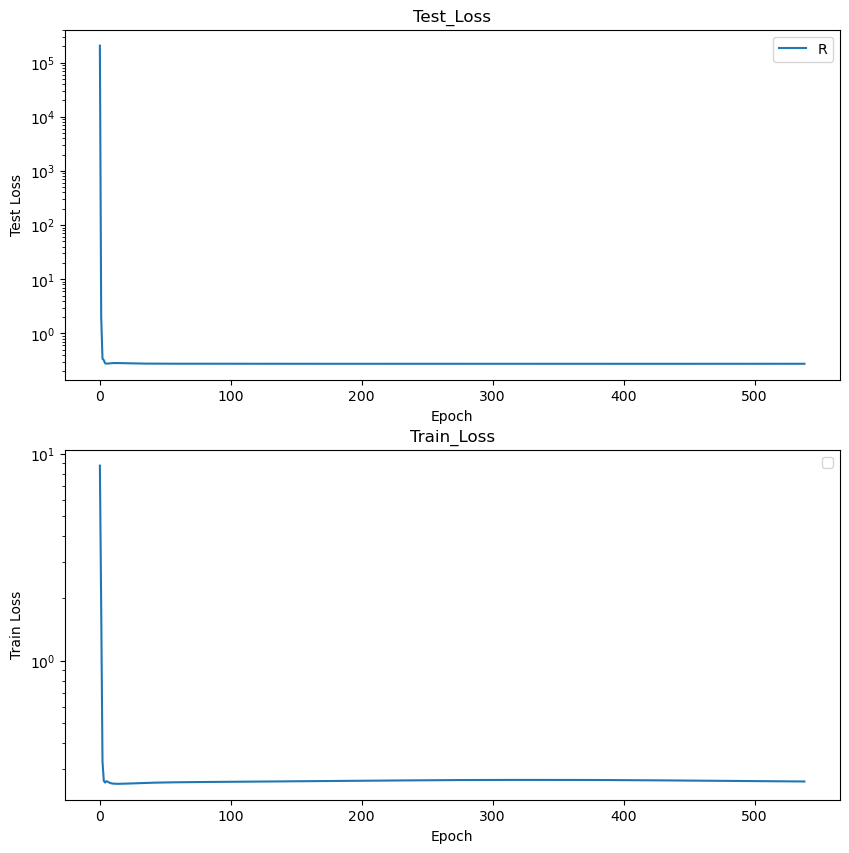

saving work is done
finish--------------------------------------------------------------------------------------------------------------------------------------------------------



No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


act:  ReLU opt:  Adam batch_size:  8 learningRate:  0.5 epoch:   553 , RMSE_Test: 3.85971 , RMSE_Train: 3.75332 , est_time:   5.0 min, average_time: 0.54 s
start to save model
start to save log
my_results/1695955271_0.52final.pt
, layer_dim_list: [2200, 1000, 100, 10, 1] activateion: ReLU , optimizer: Adam , Bsize: 8 , learningRate: 0.5
, epoch:   553 , passed_time: 5.005 m , minimum_RMSE: inf , test_loss: 3.859714 , train_loss: 3.753318 , passed_time_accum: 10.019 m model_save_time 1695955572
start to save figures


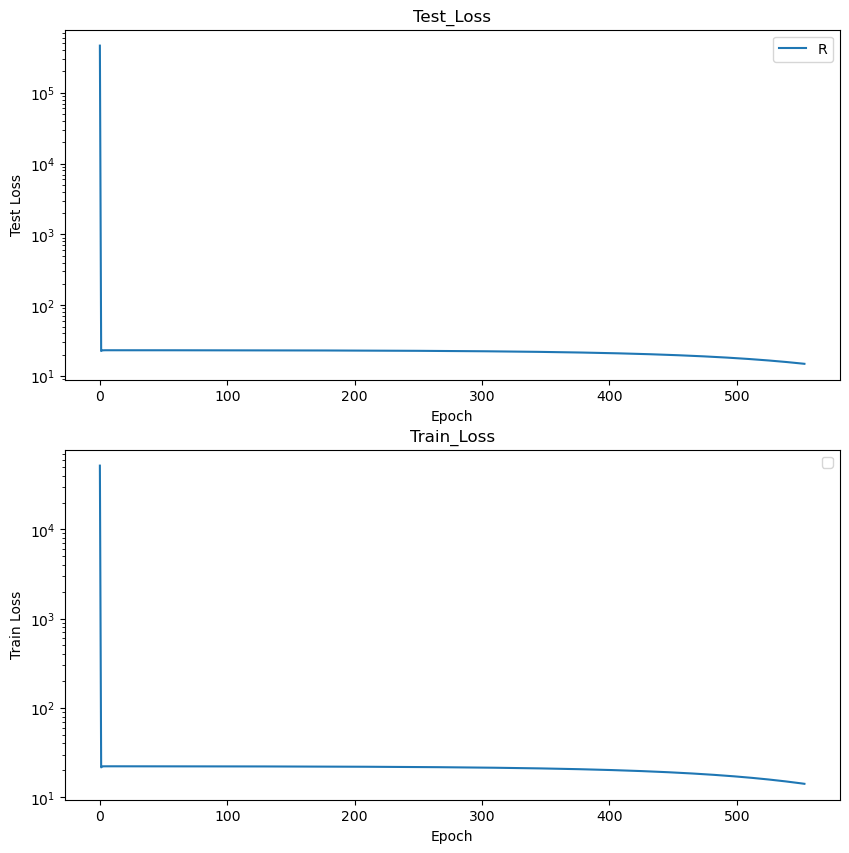

saving work is done
finish--------------------------------------------------------------------------------------------------------------------------------------------------------



No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


act:  ReLU opt:  Adam batch_size:  8 learningRate:  0.01 epoch:   614 , RMSE_Test: 0.52390 , RMSE_Train: 0.51810 , est_time:   5.0 min, average_time: 0.49 s
start to save model
start to save log
my_results/1695955873_0.52final.pt
, layer_dim_list: [2200, 1000, 100, 10, 1] activateion: ReLU , optimizer: Adam , Bsize: 8 , learningRate: 0.01
, epoch:   614 , passed_time: 5.009 m , minimum_RMSE: inf , test_loss: 0.523901 , train_loss: 0.518097 , passed_time_accum: 15.042 m model_save_time 1695955873
start to save figures


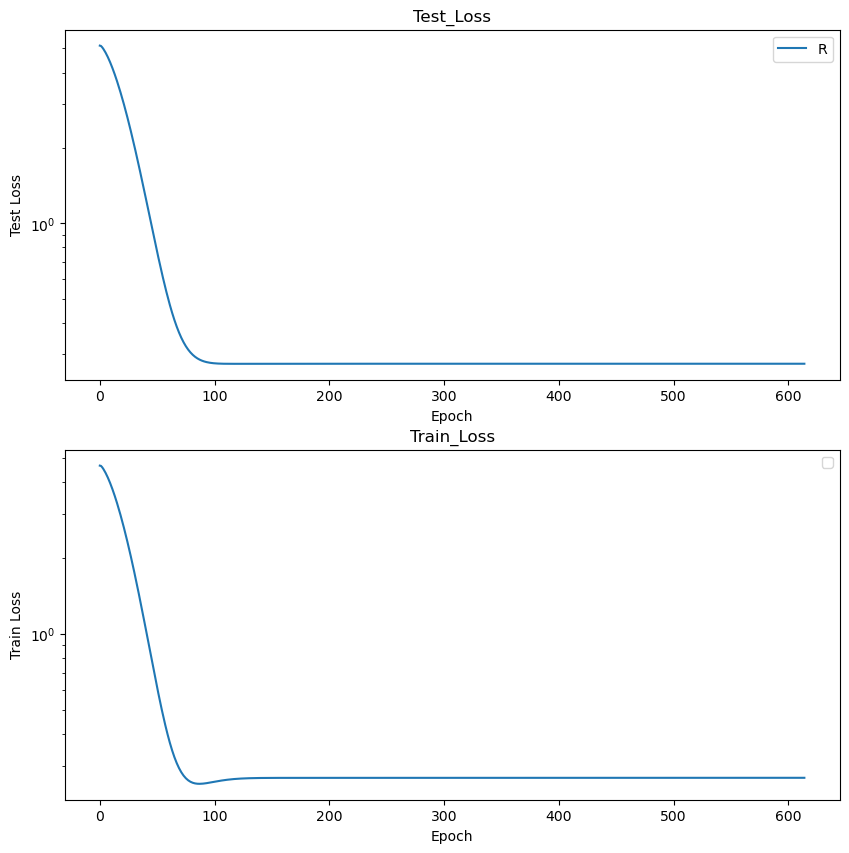

saving work is done
finish--------------------------------------------------------------------------------------------------------------------------------------------------------



No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


act:  ReLU opt:  Adam batch_size:  8 learningRate:  0.05 epoch:   642 , RMSE_Test: 0.52414 , RMSE_Train: 0.51221 , est_time:   5.0 min, average_time: 0.47 s
start to save model
start to save log
my_results/1695956174_0.52final.pt
, layer_dim_list: [2200, 1000, 100, 10, 1] activateion: ReLU , optimizer: Adam , Bsize: 8 , learningRate: 0.05
, epoch:   642 , passed_time: 5.003 m , minimum_RMSE: inf , test_loss: 0.524136 , train_loss: 0.512205 , passed_time_accum: 20.055 m model_save_time 1695956174
start to save figures


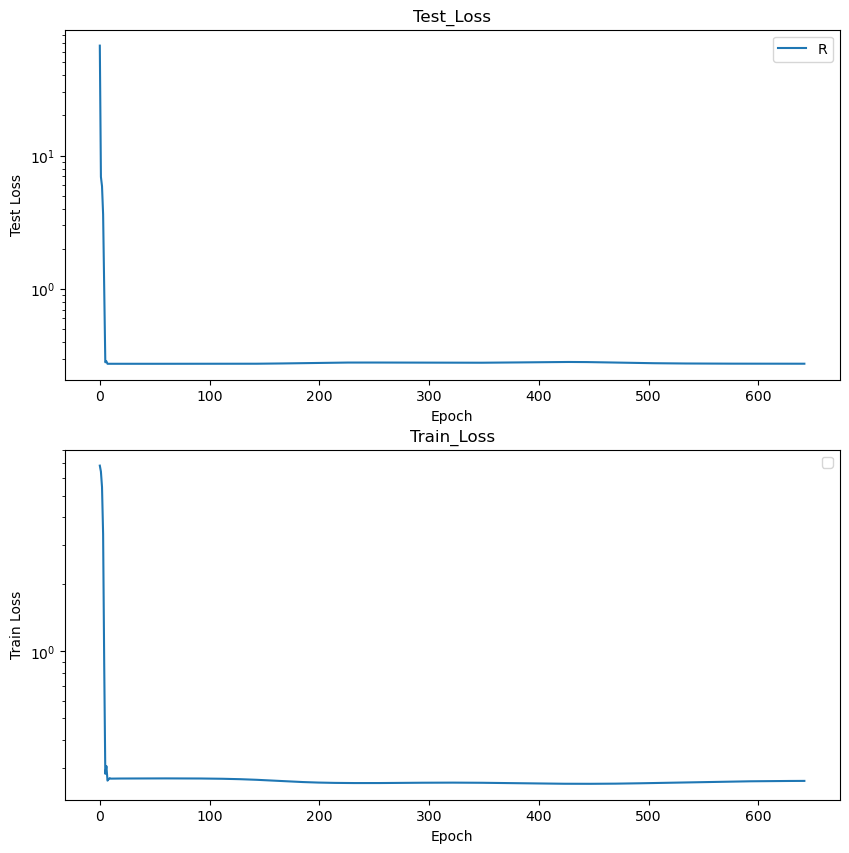

saving work is done
finish--------------------------------------------------------------------------------------------------------------------------------------------------------



No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


act:  ReLU opt:  Adam batch_size:  8 learningRate:  0.001 epoch:   625 , RMSE_Test: 0.34963 , RMSE_Train: 0.14364 , est_time:   5.0 min, average_time: 0.48 s
start to save model
start to save log
my_results/1695956475_0.34final.pt
, layer_dim_list: [2200, 1000, 100, 10, 1] activateion: ReLU , optimizer: Adam , Bsize: 8 , learningRate: 0.001
, epoch:   625 , passed_time: 5.007 m , minimum_RMSE: inf , test_loss: 0.349627 , train_loss: 0.143645 , passed_time_accum: 25.072 m model_save_time 1695956475
start to save figures


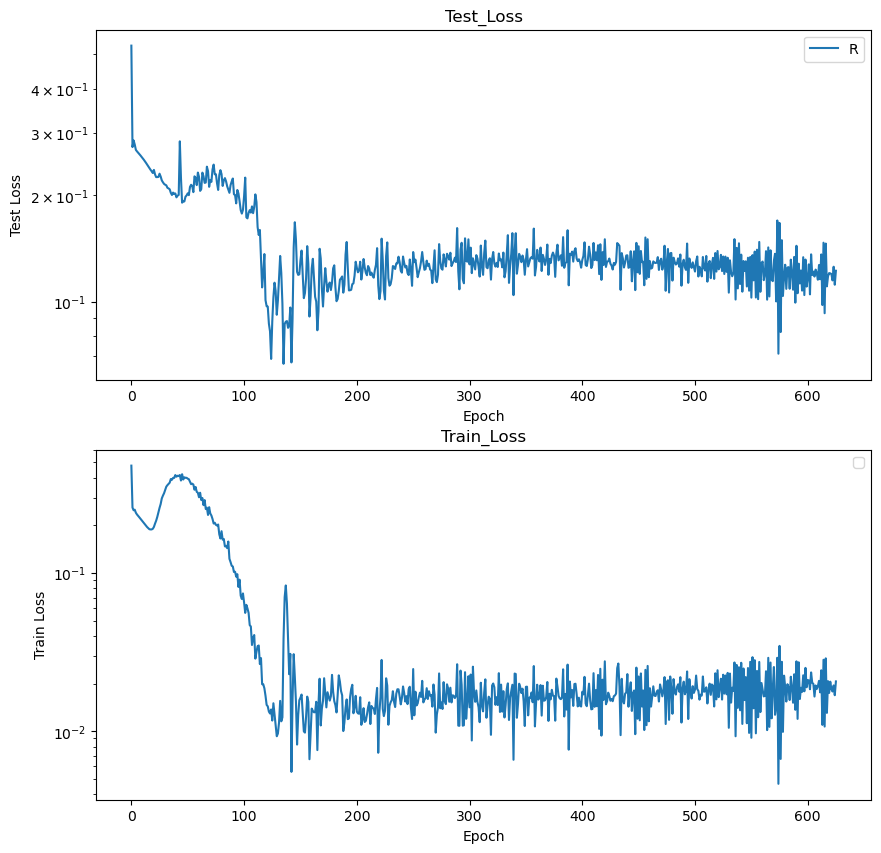

saving work is done
finish--------------------------------------------------------------------------------------------------------------------------------------------------------



No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


act:  ReLU opt:  Adam batch_size:  8 learningRate:  0.005 epoch:  1393 , RMSE_Test: 0.38072 , RMSE_Train: 0.19680 , est_time:   5.0 min, average_time: 0.22 s
start to save model
start to save log
my_results/1695956776_0.38final.pt
, layer_dim_list: [2200, 1000, 100, 10, 1] activateion: ReLU , optimizer: Adam , Bsize: 8 , learningRate: 0.005
, epoch:  1393 , passed_time: 5.004 m , minimum_RMSE: inf , test_loss: 0.380716 , train_loss: 0.196805 , passed_time_accum: 30.087 m model_save_time 1695956776
start to save figures


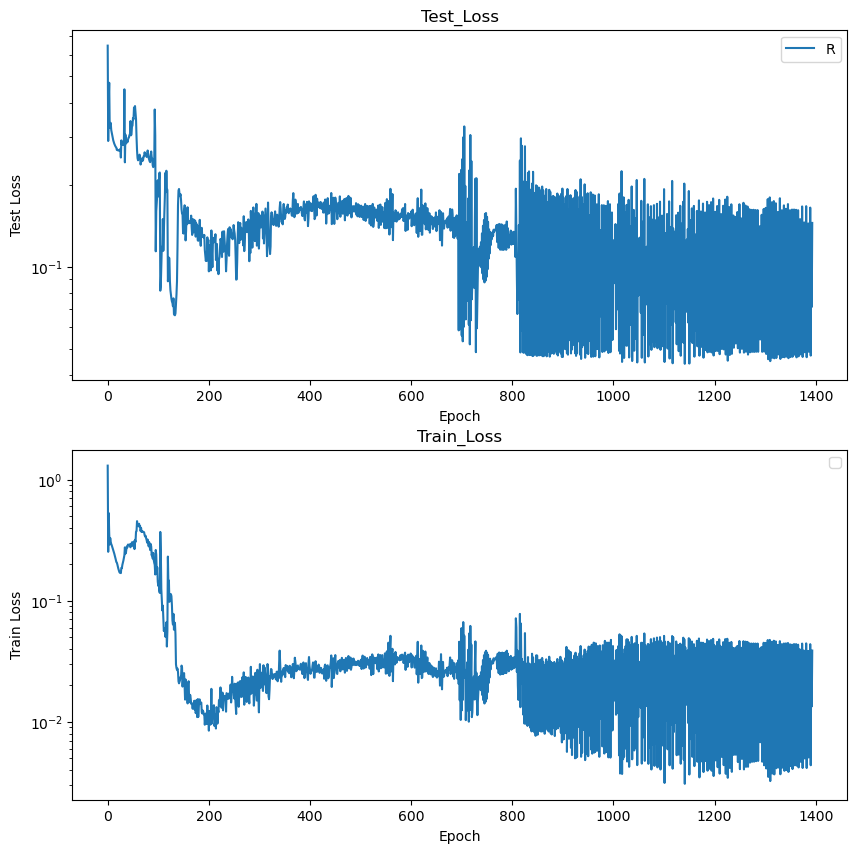

saving work is done
finish--------------------------------------------------------------------------------------------------------------------------------------------------------



No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


act:  ReLU opt:  Adam batch_size:  8 learningRate:  0.0001 epoch:   633 , RMSE_Test: 0.34034 , RMSE_Train: 0.11363 , est_time:   5.0 min, average_time: 0.47 s
start to save model
start to save log
my_results/1695957077_0.34final.pt
, layer_dim_list: [2200, 1000, 100, 10, 1] activateion: ReLU , optimizer: Adam , Bsize: 8 , learningRate: 0.0001
, epoch:   633 , passed_time: 5.003 m , minimum_RMSE: inf , test_loss: 0.340340 , train_loss: 0.113634 , passed_time_accum: 35.102 m model_save_time 1695957077
start to save figures


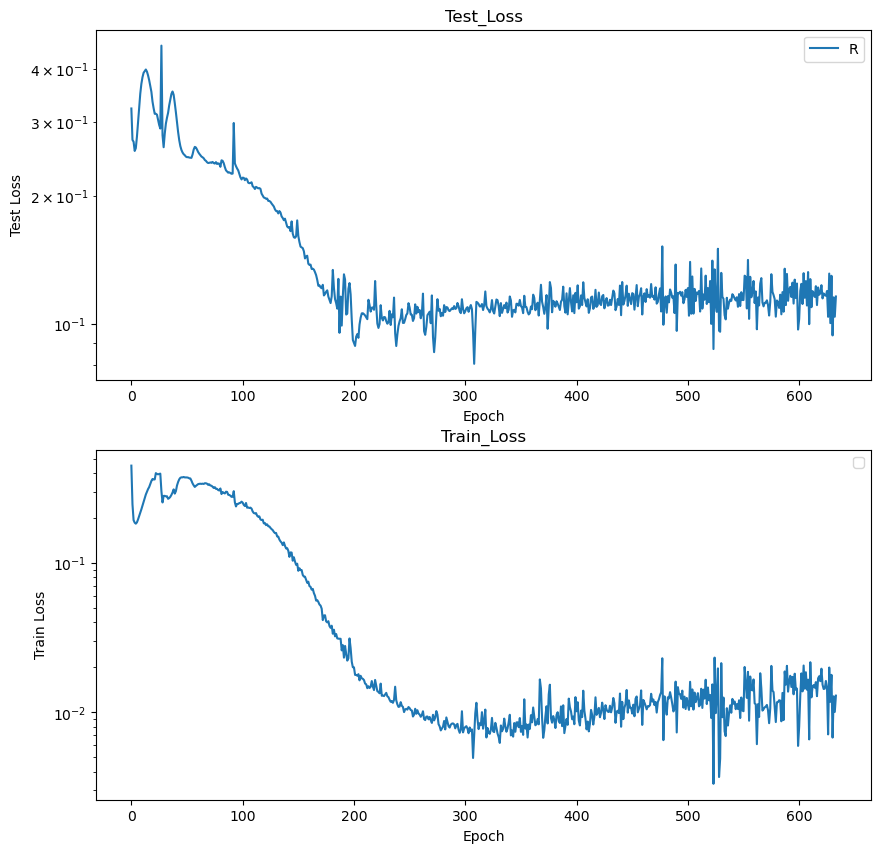

saving work is done
finish--------------------------------------------------------------------------------------------------------------------------------------------------------



No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


act:  ReLU opt:  Adam batch_size:  8 learningRate:  0.0005 epoch:  1681 , RMSE_Test: 0.26483 , RMSE_Train: 0.14759 , est_time:   5.0 min, average_time: 0.18 s
start to save model
start to save log
my_results/1695957378_0.26final.pt
, layer_dim_list: [2200, 1000, 100, 10, 1] activateion: ReLU , optimizer: Adam , Bsize: 8 , learningRate: 0.0005
, epoch:  1681 , passed_time: 5.003 m , minimum_RMSE: inf , test_loss: 0.264832 , train_loss: 0.147594 , passed_time_accum: 40.119 m model_save_time 1695957378
start to save figures


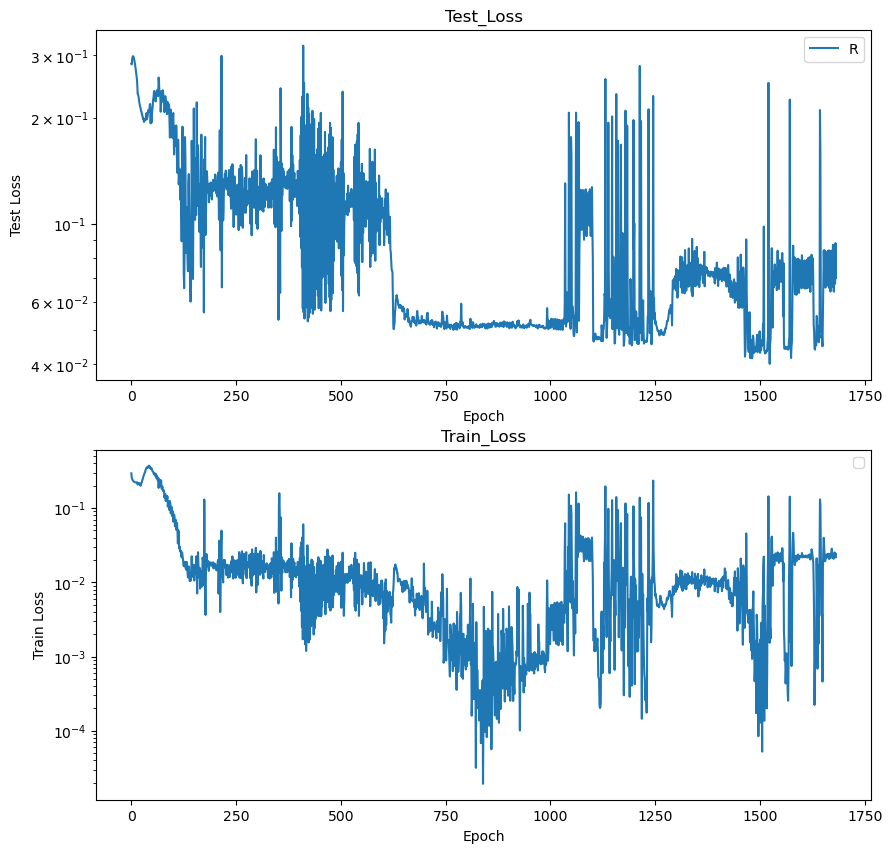

saving work is done
finish--------------------------------------------------------------------------------------------------------------------------------------------------------



No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


act:  ReLU opt:  Adam batch_size:  8 learningRate:  1e-05 epoch:  1676 , RMSE_Test: 0.27535 , RMSE_Train: 0.04618 , est_time:   5.0 min, average_time: 0.18 s
start to save model
start to save log
my_results/1695957679_0.27final.pt
, layer_dim_list: [2200, 1000, 100, 10, 1] activateion: ReLU , optimizer: Adam , Bsize: 8 , learningRate: 1e-05
, epoch:  1676 , passed_time: 5.000 m , minimum_RMSE: inf , test_loss: 0.275349 , train_loss: 0.046178 , passed_time_accum: 45.134 m model_save_time 1695957679
start to save figures


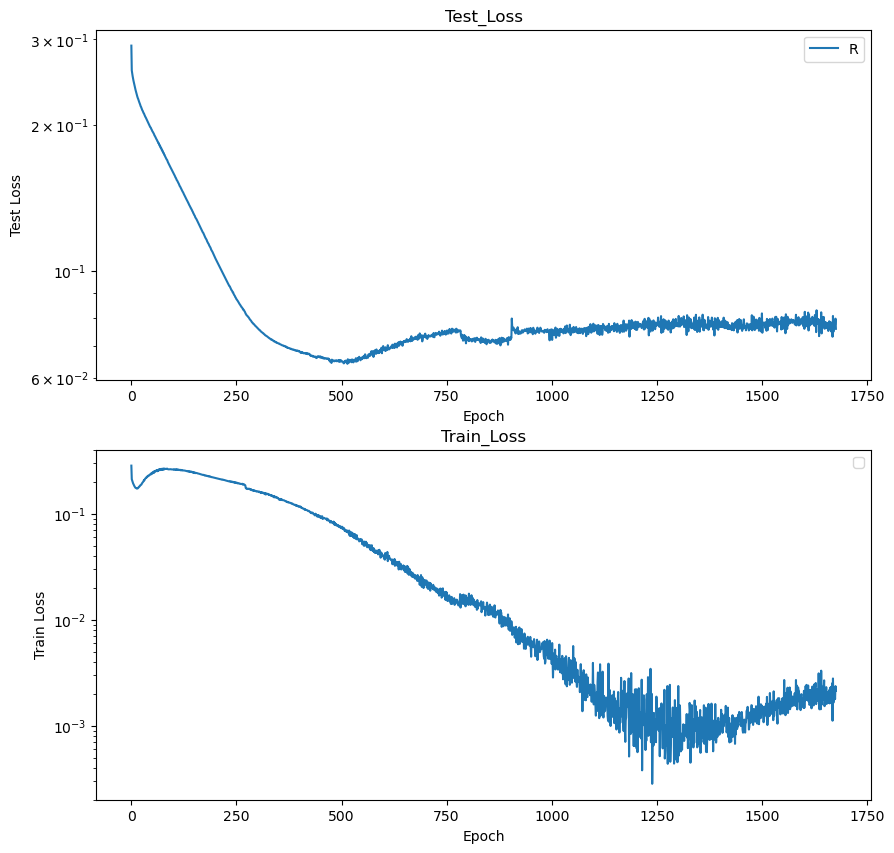

saving work is done
finish--------------------------------------------------------------------------------------------------------------------------------------------------------

act:  ReLU opt:  Adam batch_size:  8 learningRate:  5e-05 epoch:  1552 , RMSE_Test: 0.19863 , RMSE_Train: 0.08323 , est_time:   4.7 min, average_time: 0.18 s


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


act:  ReLU opt:  Adam batch_size:  8 learningRate:  5e-05 epoch:  1639 , RMSE_Test: 0.20467 , RMSE_Train: 0.04514 , est_time:   5.0 min, average_time: 0.18 s
start to save model
start to save log
my_results/1695957980_0.20final.pt
, layer_dim_list: [2200, 1000, 100, 10, 1] activateion: ReLU , optimizer: Adam , Bsize: 8 , learningRate: 5e-05
, epoch:  1639 , passed_time: 5.001 m , minimum_RMSE: 0.19863 , test_loss: 0.204672 , train_loss: 0.045140 , passed_time_accum: 50.147 m model_save_time 1695957980
start to save figures


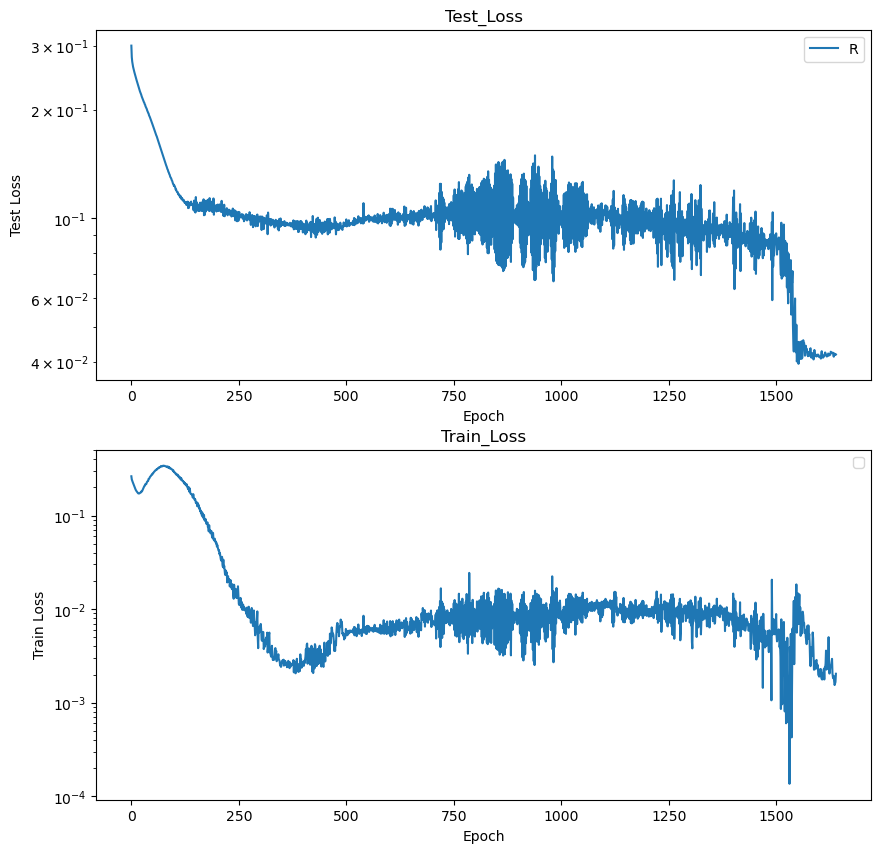

saving work is done
finish--------------------------------------------------------------------------------------------------------------------------------------------------------



No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


act:  ReLU opt:  Adam batch_size:  8 learningRate:  1e-06 epoch:   614 , RMSE_Test: 0.44978 , RMSE_Train: 0.49658 , est_time:   5.0 min, average_time: 0.49 s
start to save model
start to save log
my_results/1695958281_0.44final.pt
, layer_dim_list: [2200, 1000, 100, 10, 1] activateion: ReLU , optimizer: Adam , Bsize: 8 , learningRate: 1e-06
, epoch:   614 , passed_time: 5.001 m , minimum_RMSE: 0.19863 , test_loss: 0.449776 , train_loss: 0.496585 , passed_time_accum: 55.161 m model_save_time 1695958281
start to save figures


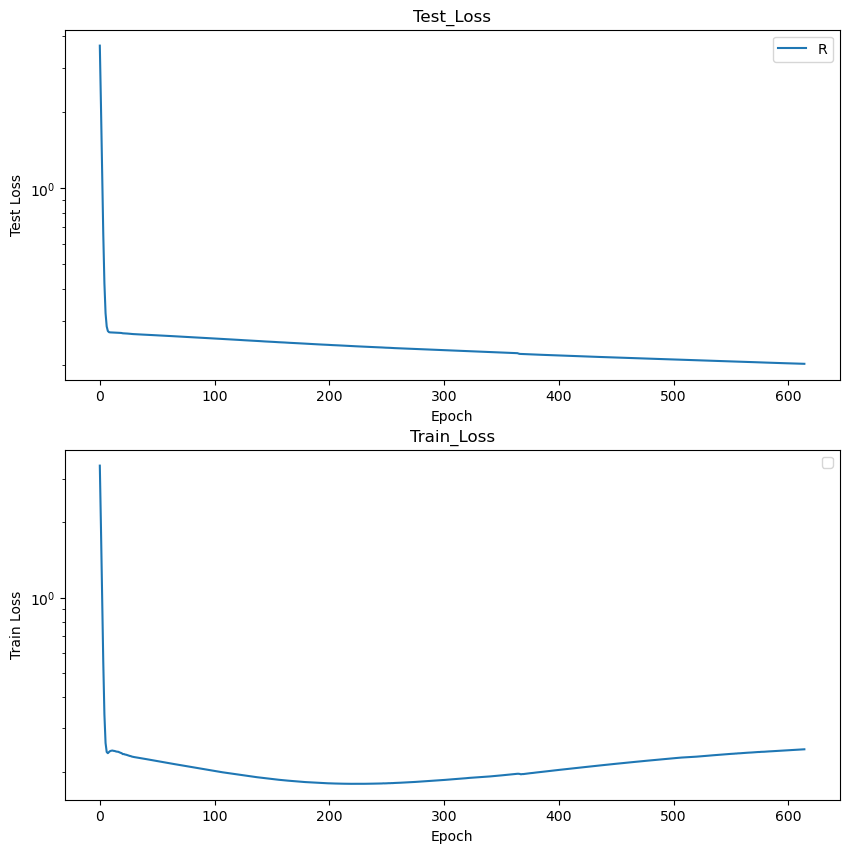

saving work is done
finish--------------------------------------------------------------------------------------------------------------------------------------------------------



No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


act:  ReLU opt:  Adam batch_size:  8 learningRate:  5e-06 epoch:   640 , RMSE_Test: 0.36924 , RMSE_Train: 0.39871 , est_time:   5.0 min, average_time: 0.47 s
start to save model
start to save log
my_results/1695958581_0.36final.pt
, layer_dim_list: [2200, 1000, 100, 10, 1] activateion: ReLU , optimizer: Adam , Bsize: 8 , learningRate: 5e-06
, epoch:   640 , passed_time: 5.003 m , minimum_RMSE: 0.19863 , test_loss: 0.369244 , train_loss: 0.398709 , passed_time_accum: 60.173 m model_save_time 1695958581
start to save figures


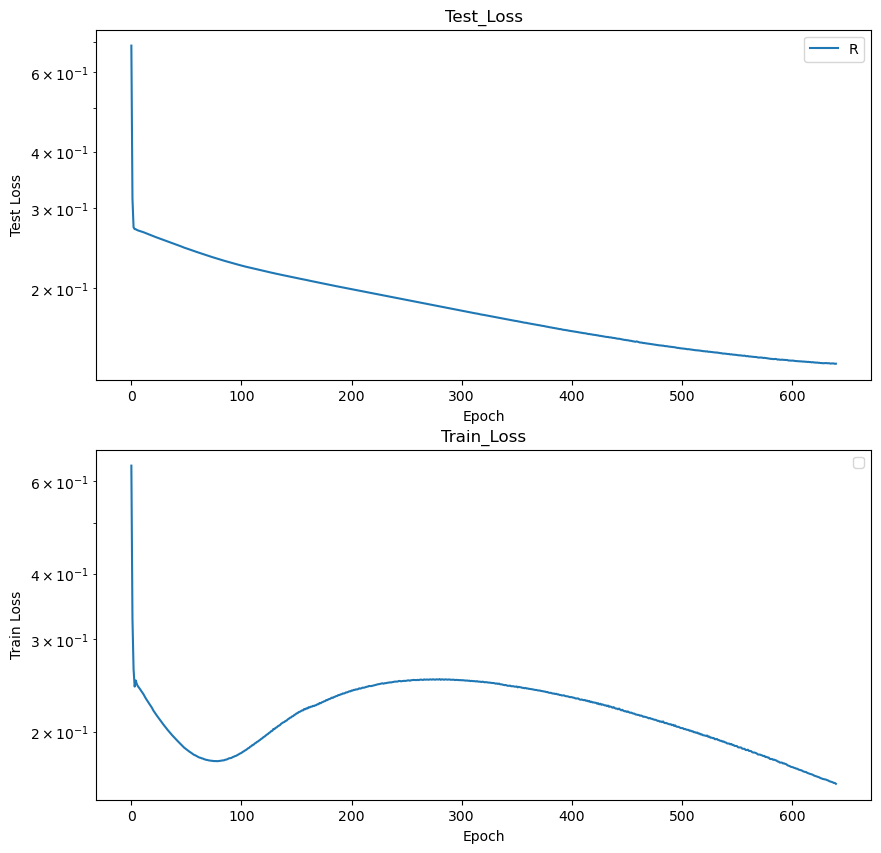

saving work is done
finish--------------------------------------------------------------------------------------------------------------------------------------------------------



No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


act:  ReLU opt:  Adam batch_size:  16 learningRate:  0.1 epoch:  1212 , RMSE_Test: 0.52388 , RMSE_Train: 0.40488 , est_time:   5.0 min, average_time: 0.25 s
start to save model
start to save log
my_results/1695958882_0.52final.pt
, layer_dim_list: [2200, 1000, 100, 10, 1] activateion: ReLU , optimizer: Adam , Bsize: 16 , learningRate: 0.1
, epoch:  1212 , passed_time: 5.002 m , minimum_RMSE: 0.19863 , test_loss: 0.523875 , train_loss: 0.404882 , passed_time_accum: 65.185 m model_save_time 1695958882
start to save figures


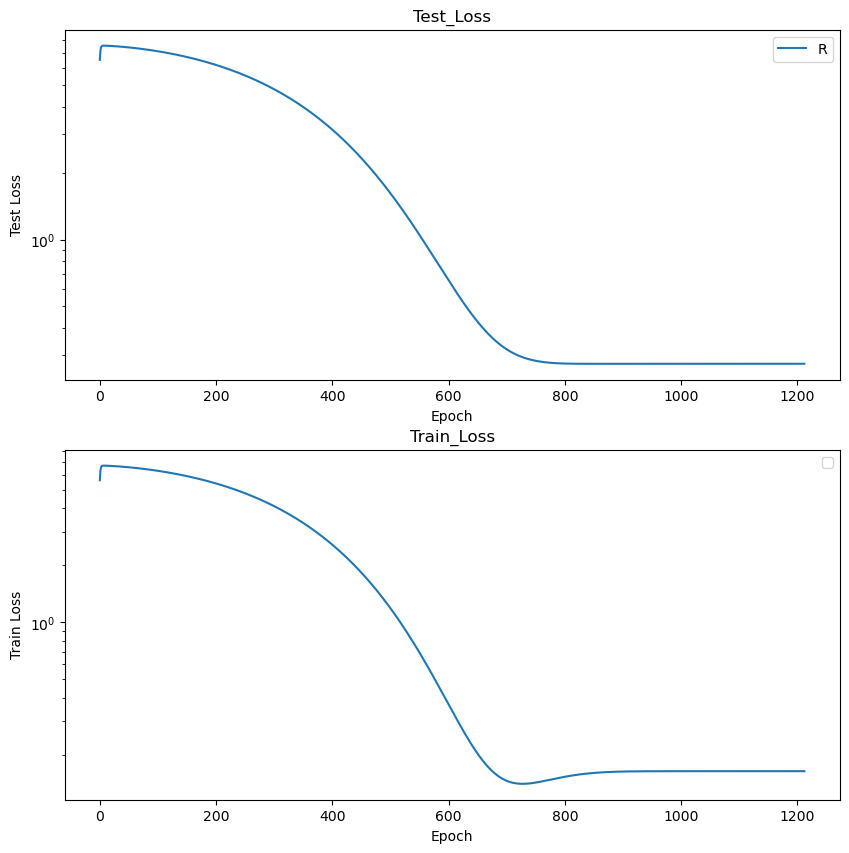

saving work is done
finish--------------------------------------------------------------------------------------------------------------------------------------------------------



No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


act:  ReLU opt:  Adam batch_size:  16 learningRate:  0.5 epoch:  1211 , RMSE_Test: 3.67903 , RMSE_Train: 3.52227 , est_time:   5.0 min, average_time: 0.25 s
start to save model
start to save log
my_results/1695959183_3final.pt
, layer_dim_list: [2200, 1000, 100, 10, 1] activateion: ReLU , optimizer: Adam , Bsize: 16 , learningRate: 0.5
, epoch:  1211 , passed_time: 5.004 m , minimum_RMSE: 0.19863 , test_loss: 3.679026 , train_loss: 3.522271 , passed_time_accum: 70.198 m model_save_time 1695959183
start to save figures


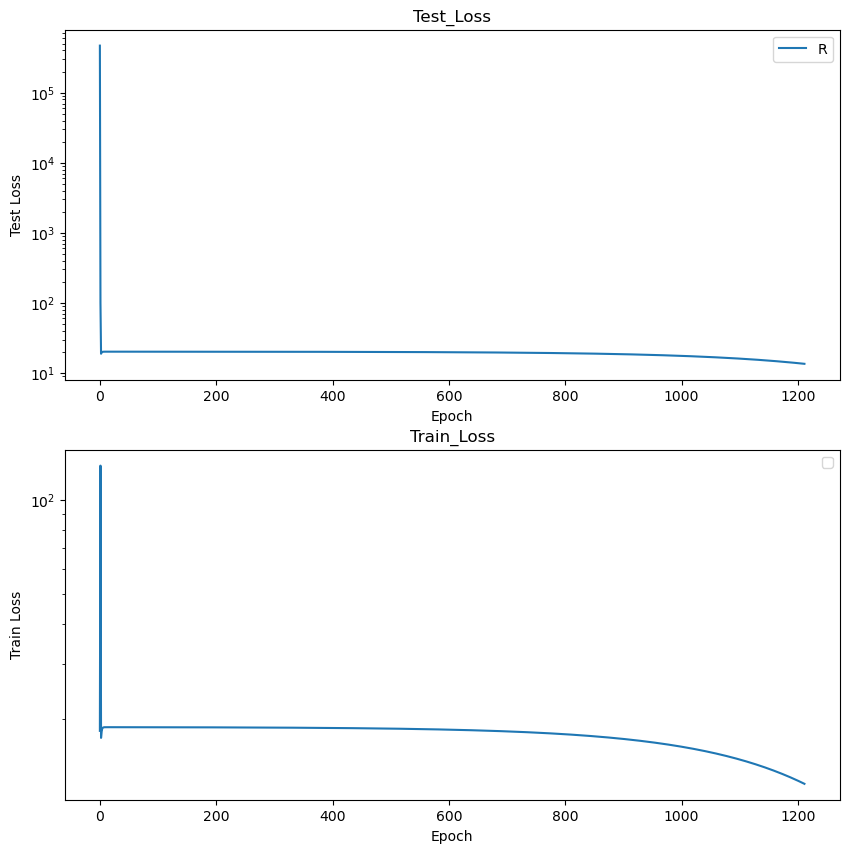

saving work is done
finish--------------------------------------------------------------------------------------------------------------------------------------------------------



No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


act:  ReLU opt:  Adam batch_size:  16 learningRate:  0.01 epoch:  3195 , RMSE_Test: 0.52387 , RMSE_Train: 0.40510 , est_time:   5.0 min, average_time: 0.09 s
start to save model
start to save log
my_results/1695959484_0.52final.pt
, layer_dim_list: [2200, 1000, 100, 10, 1] activateion: ReLU , optimizer: Adam , Bsize: 16 , learningRate: 0.01
, epoch:  3195 , passed_time: 5.001 m , minimum_RMSE: 0.19863 , test_loss: 0.523872 , train_loss: 0.405105 , passed_time_accum: 75.215 m model_save_time 1695959484
start to save figures


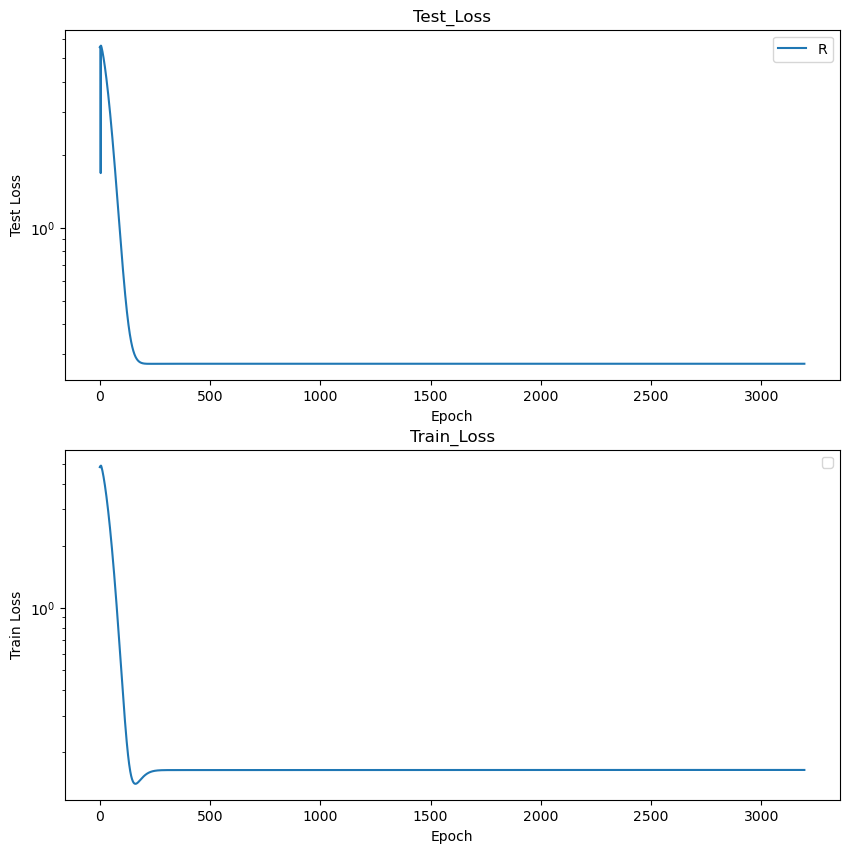

saving work is done
finish--------------------------------------------------------------------------------------------------------------------------------------------------------



No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


act:  ReLU opt:  Adam batch_size:  16 learningRate:  0.05 epoch:  3215 , RMSE_Test: 0.52385 , RMSE_Train: 0.40633 , est_time:   5.0 min, average_time: 0.09 s
start to save model
start to save log
my_results/1695959785_0.52final.pt
, layer_dim_list: [2200, 1000, 100, 10, 1] activateion: ReLU , optimizer: Adam , Bsize: 16 , learningRate: 0.05
, epoch:  3215 , passed_time: 5.001 m , minimum_RMSE: 0.19863 , test_loss: 0.523853 , train_loss: 0.406332 , passed_time_accum: 80.225 m model_save_time 1695959785
start to save figures


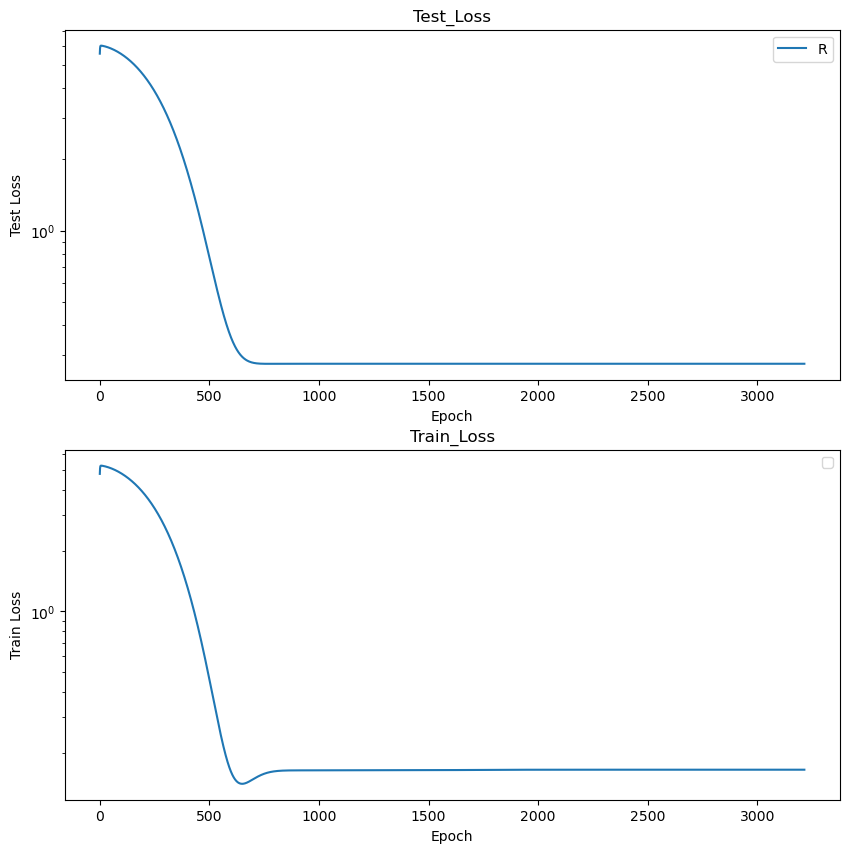

saving work is done
finish--------------------------------------------------------------------------------------------------------------------------------------------------------

act:  ReLU opt:  Adam batch_size:  16 learningRate:  0.001 epoch:  1405 , RMSE_Test: 0.19600 , RMSE_Train: 0.15411 , est_time:   2.2 min, average_time: 0.09 s
act:  ReLU opt:  Adam batch_size:  16 learningRate:  0.001 epoch:  1523 , RMSE_Test: 0.19569 , RMSE_Train: 0.14420 , est_time:   2.4 min, average_time: 0.09 s
act:  ReLU opt:  Adam batch_size:  16 learningRate:  0.001 epoch:  1629 , RMSE_Test: 0.19458 , RMSE_Train: 0.13887 , est_time:   2.5 min, average_time: 0.09 s
act:  ReLU opt:  Adam batch_size:  16 learningRate:  0.001 epoch:  1642 , RMSE_Test: 0.19373 , RMSE_Train: 0.15493 , est_time:   2.5 min, average_time: 0.09 s
act:  ReLU opt:  Adam batch_size:  16 learningRate:  0.001 epoch:  1703 , RMSE_Test: 0.19181 , RMSE_Train: 0.16623 , est_time:   2.6 min, average_time: 0.09 s


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


act:  ReLU opt:  Adam batch_size:  16 learningRate:  0.001 epoch:  3233 , RMSE_Test: 0.23570 , RMSE_Train: 0.15441 , est_time:   5.0 min, average_time: 0.09 s
start to save model
start to save log
my_results/1695960085_0.23final.pt
, layer_dim_list: [2200, 1000, 100, 10, 1] activateion: ReLU , optimizer: Adam , Bsize: 16 , learningRate: 0.001
, epoch:  3233 , passed_time: 5.001 m , minimum_RMSE: 0.19181 , test_loss: 0.235699 , train_loss: 0.154410 , passed_time_accum: 85.236 m model_save_time 1695960085
start to save figures


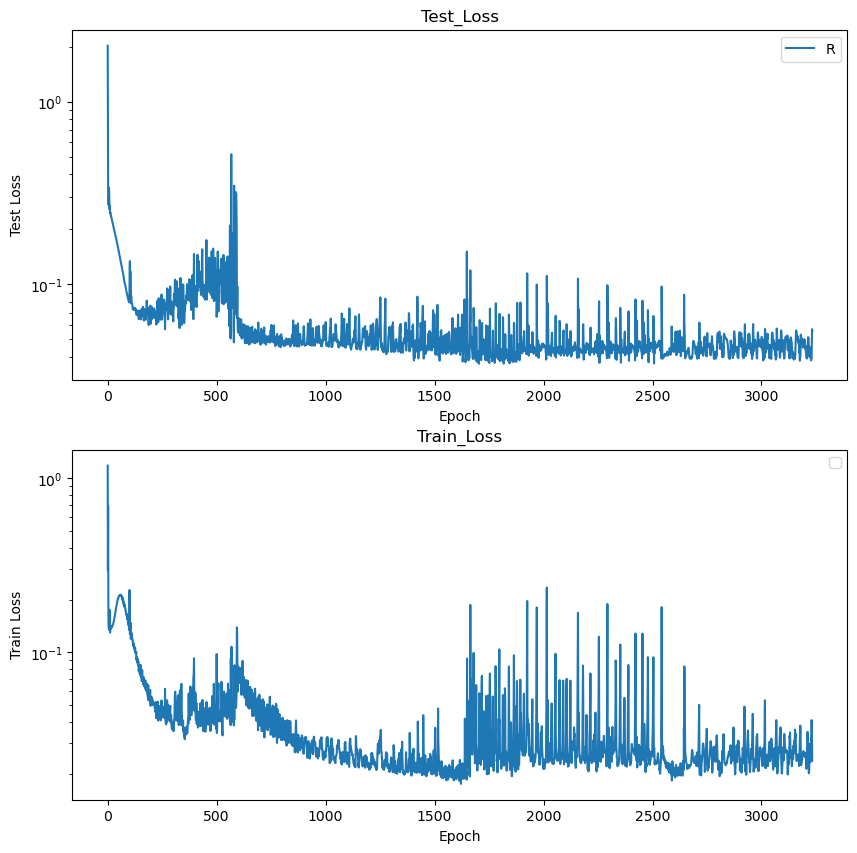

saving work is done
finish--------------------------------------------------------------------------------------------------------------------------------------------------------



No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


act:  ReLU opt:  Adam batch_size:  16 learningRate:  0.005 epoch:  3227 , RMSE_Test: 0.28281 , RMSE_Train: 0.13515 , est_time:   5.0 min, average_time: 0.09 s
start to save model
start to save log
my_results/1695960386_0.28final.pt
, layer_dim_list: [2200, 1000, 100, 10, 1] activateion: ReLU , optimizer: Adam , Bsize: 16 , learningRate: 0.005
, epoch:  3227 , passed_time: 5.000 m , minimum_RMSE: 0.19181 , test_loss: 0.282807 , train_loss: 0.135150 , passed_time_accum: 90.247 m model_save_time 1695960386
start to save figures


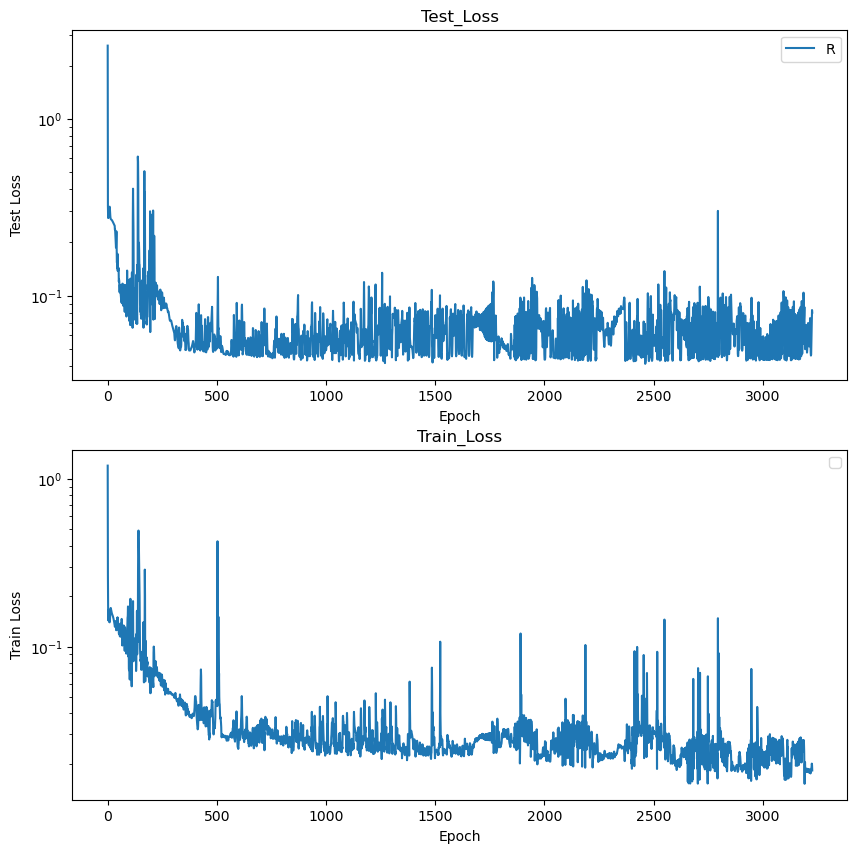

saving work is done
finish--------------------------------------------------------------------------------------------------------------------------------------------------------

act:  ReLU opt:  Adam batch_size:  16 learningRate:  0.0001 epoch:  1390 , RMSE_Test: 0.19071 , RMSE_Train: 0.16352 , est_time:   3.9 min, average_time: 0.17 s
act:  ReLU opt:  Adam batch_size:  16 learningRate:  0.0001 epoch:  1441 , RMSE_Test: 0.18758 , RMSE_Train: 0.14187 , est_time:   4.1 min, average_time: 0.17 s


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


act:  ReLU opt:  Adam batch_size:  16 learningRate:  0.0001 epoch:  1775 , RMSE_Test: 0.23320 , RMSE_Train: 0.14858 , est_time:   5.0 min, average_time: 0.17 s
start to save model
start to save log
my_results/1695960687_0.23final.pt
, layer_dim_list: [2200, 1000, 100, 10, 1] activateion: ReLU , optimizer: Adam , Bsize: 16 , learningRate: 0.0001
, epoch:  1775 , passed_time: 5.002 m , minimum_RMSE: 0.18758 , test_loss: 0.233201 , train_loss: 0.148582 , passed_time_accum: 95.260 m model_save_time 1695960687
start to save figures


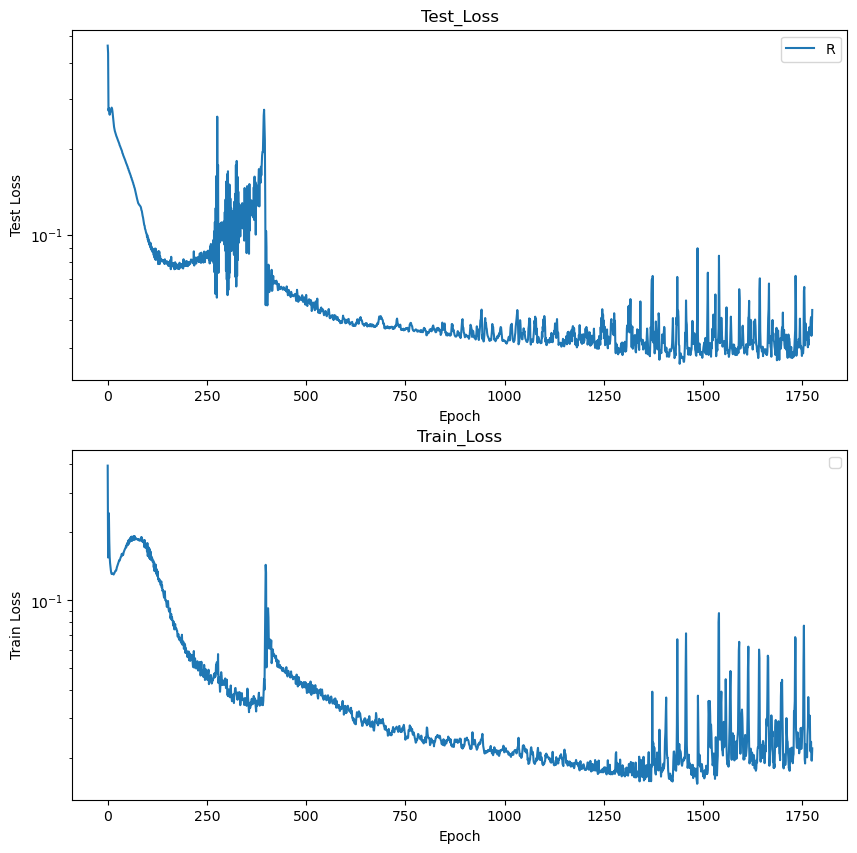

saving work is done
finish--------------------------------------------------------------------------------------------------------------------------------------------------------



No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


act:  ReLU opt:  Adam batch_size:  16 learningRate:  0.0005 epoch:  1233 , RMSE_Test: 0.20514 , RMSE_Train: 0.14784 , est_time:   5.0 min, average_time: 0.24 s
start to save model
start to save log
my_results/1695960987_0.20final.pt
, layer_dim_list: [2200, 1000, 100, 10, 1] activateion: ReLU , optimizer: Adam , Bsize: 16 , learningRate: 0.0005
, epoch:  1233 , passed_time: 5.001 m , minimum_RMSE: 0.18758 , test_loss: 0.205141 , train_loss: 0.147835 , passed_time_accum: 100.271 m model_save_time 1695960987
start to save figures


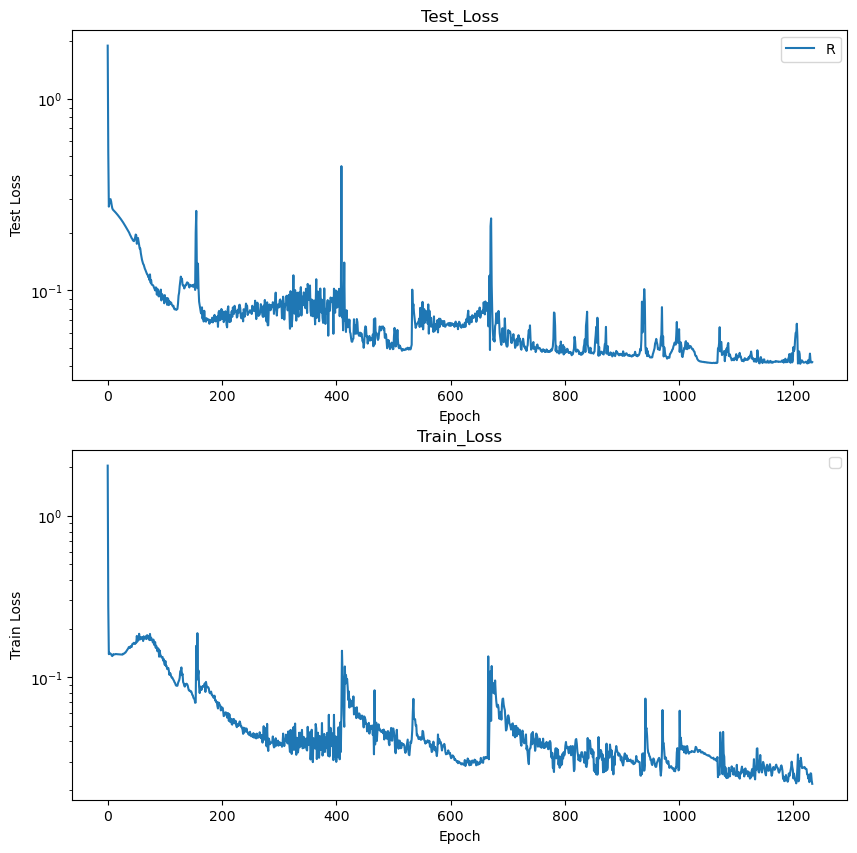

saving work is done
finish--------------------------------------------------------------------------------------------------------------------------------------------------------



No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


act:  ReLU opt:  Adam batch_size:  16 learningRate:  1e-05 epoch:  1070 , RMSE_Test: 0.29961 , RMSE_Train: 0.24166 , est_time:   5.0 min, average_time: 0.28 s
start to save model
start to save log
my_results/1695961288_0.29final.pt
, layer_dim_list: [2200, 1000, 100, 10, 1] activateion: ReLU , optimizer: Adam , Bsize: 16 , learningRate: 1e-05
, epoch:  1070 , passed_time: 5.000 m , minimum_RMSE: 0.18758 , test_loss: 0.299609 , train_loss: 0.241664 , passed_time_accum: 105.282 m model_save_time 1695961288
start to save figures


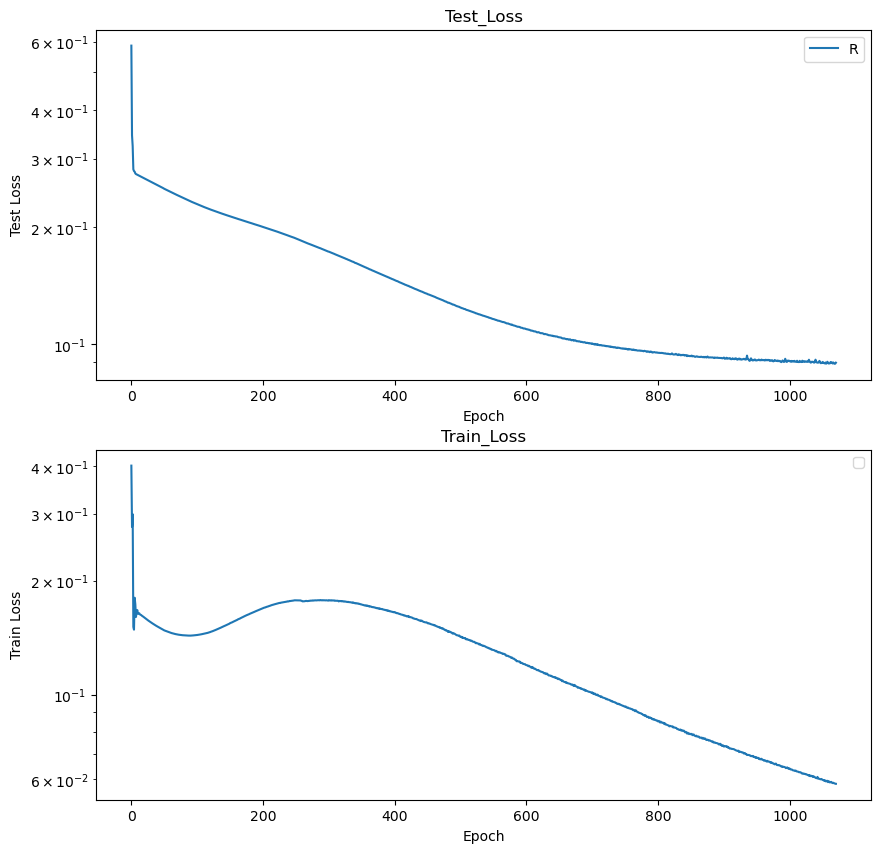

saving work is done
finish--------------------------------------------------------------------------------------------------------------------------------------------------------



No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


act:  ReLU opt:  Adam batch_size:  16 learningRate:  5e-05 epoch:  2605 , RMSE_Test: 0.20146 , RMSE_Train: 0.16114 , est_time:   5.0 min, average_time: 0.12 s
start to save model
start to save log
my_results/1695961589_0.20final.pt
, layer_dim_list: [2200, 1000, 100, 10, 1] activateion: ReLU , optimizer: Adam , Bsize: 16 , learningRate: 5e-05
, epoch:  2605 , passed_time: 5.000 m , minimum_RMSE: 0.18758 , test_loss: 0.201456 , train_loss: 0.161136 , passed_time_accum: 110.293 m model_save_time 1695961589
start to save figures


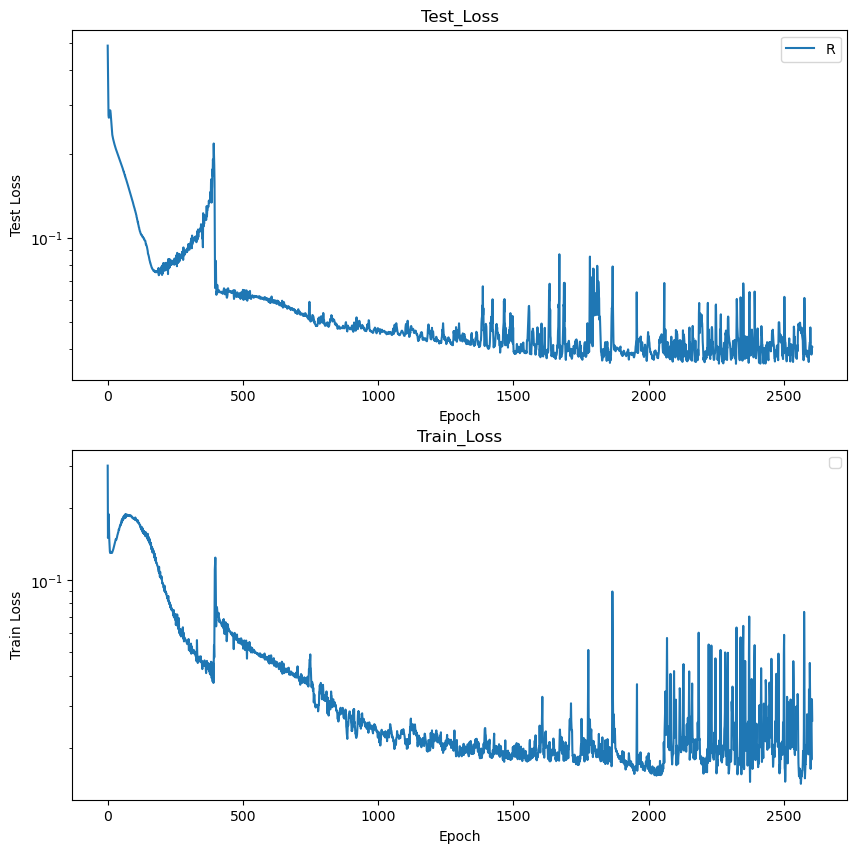

saving work is done
finish--------------------------------------------------------------------------------------------------------------------------------------------------------



No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


act:  ReLU opt:  Adam batch_size:  16 learningRate:  1e-06 epoch:  1077 , RMSE_Test: 0.46101 , RMSE_Train: 0.39714 , est_time:   5.0 min, average_time: 0.28 s
start to save model
start to save log
my_results/1695961889_0.46final.pt
, layer_dim_list: [2200, 1000, 100, 10, 1] activateion: ReLU , optimizer: Adam , Bsize: 16 , learningRate: 1e-06
, epoch:  1077 , passed_time: 5.003 m , minimum_RMSE: 0.18758 , test_loss: 0.461012 , train_loss: 0.397137 , passed_time_accum: 115.305 m model_save_time 1695961889
start to save figures


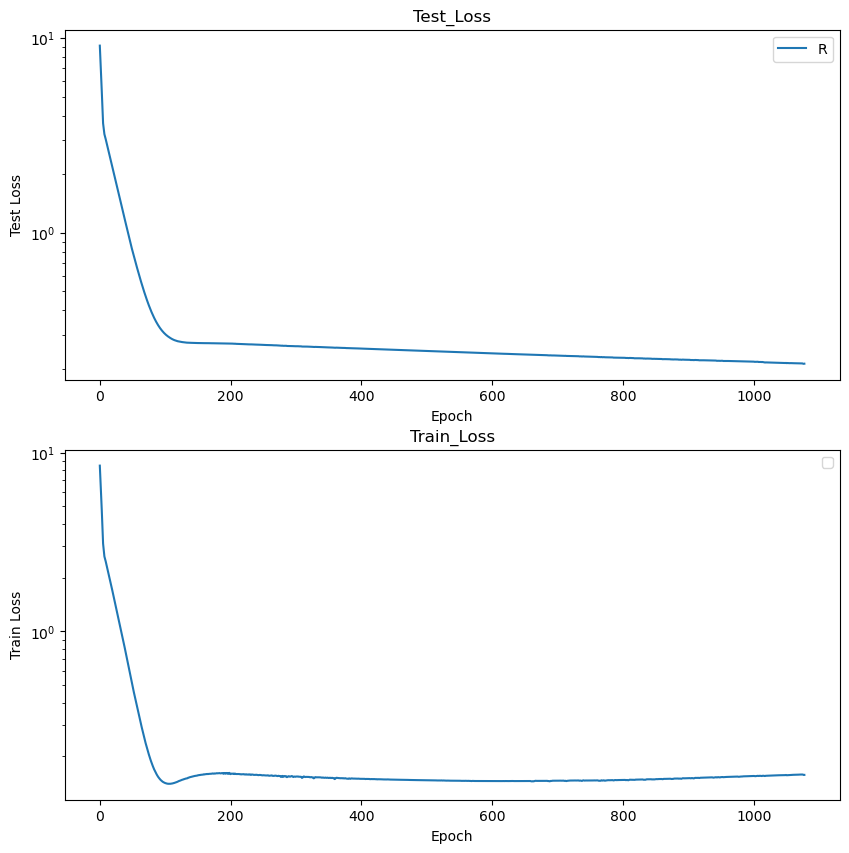

saving work is done
finish--------------------------------------------------------------------------------------------------------------------------------------------------------

act:  ReLU opt:  Adam batch_size:  16 learningRate:  5e-06 epoch:  1266 , RMSE_Test: 0.29883 , RMSE_Train: 0.32883 , est_time:   5.0 min, average_time: 0.24 s
start to save model
start to save log
my_results/1695962190_0.29final.pt
, layer_dim_list: [2200, 1000, 100, 10, 1] activateion: ReLU , optimizer: Adam , Bsize: 16 , learningRate: 5e-06
, epoch:  1266 , passed_time: 5.003 m , minimum_RMSE: 0.18758 , test_loss: 0.298828 , train_loss: 0.328835 , passed_time_accum: 120.318 m model_save_time 1695962190
start to save figures


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


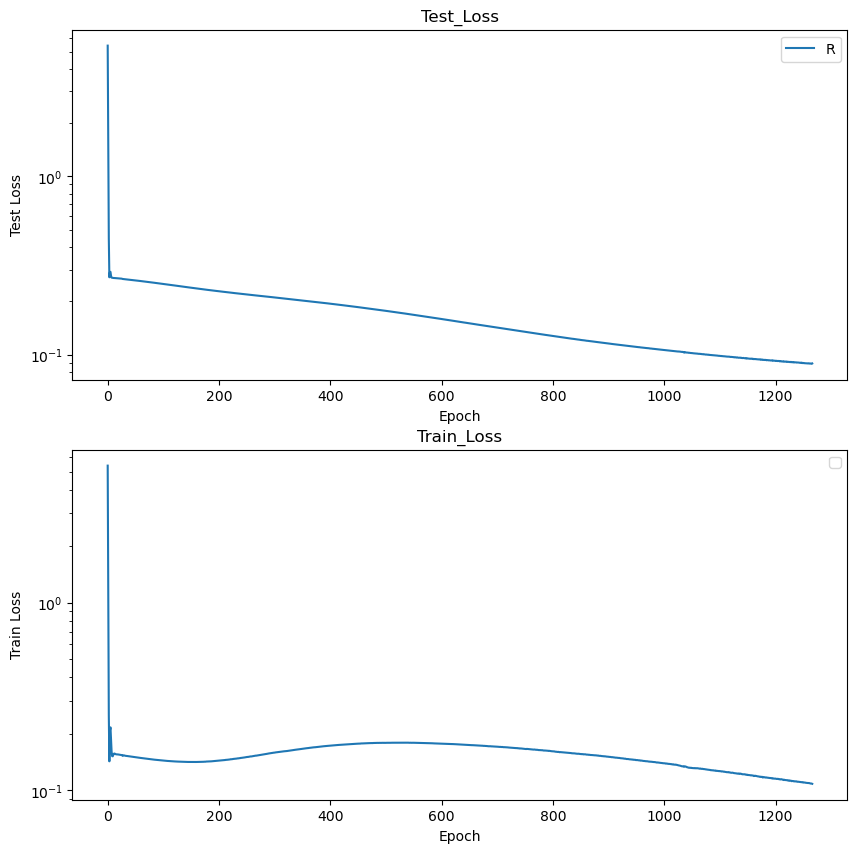

saving work is done
finish--------------------------------------------------------------------------------------------------------------------------------------------------------



No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


act:  ReLU opt:  Adam batch_size:  32 learningRate:  0.1 epoch:  6127 , RMSE_Test: 0.52378 , RMSE_Train: 0.57103 , est_time:   5.0 min, average_time: 0.05 s
start to save model
start to save log
my_results/1695962491_0.52final.pt
, layer_dim_list: [2200, 1000, 100, 10, 1] activateion: ReLU , optimizer: Adam , Bsize: 32 , learningRate: 0.1
, epoch:  6127 , passed_time: 5.000 m , minimum_RMSE: 0.18758 , test_loss: 0.523783 , train_loss: 0.571026 , passed_time_accum: 125.333 m model_save_time 1695962491
start to save figures


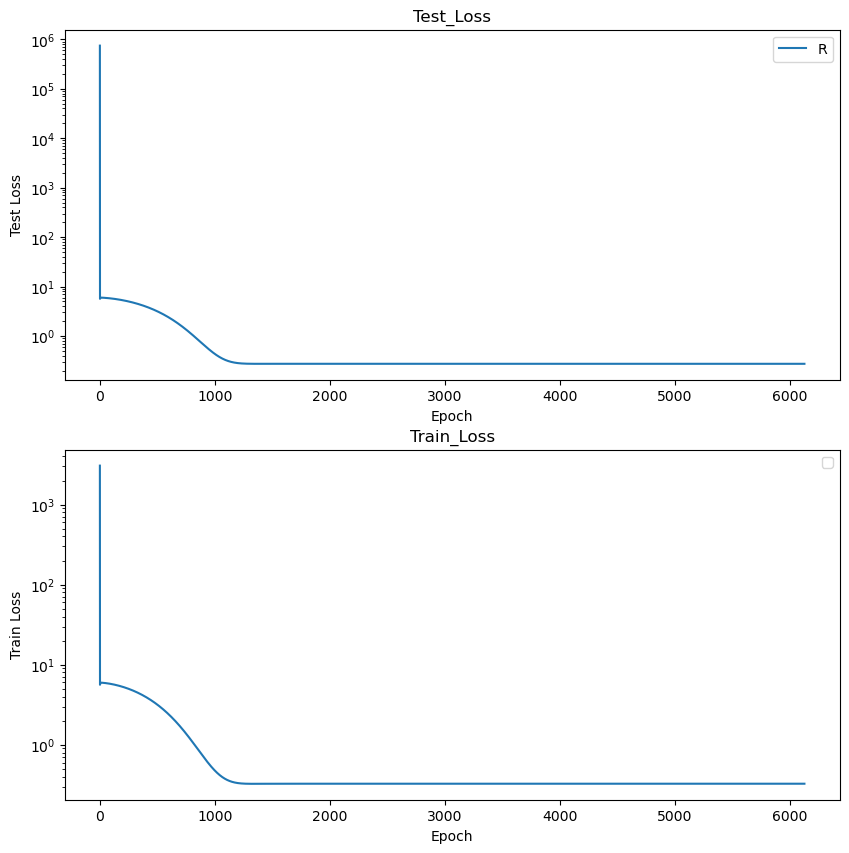

saving work is done
finish--------------------------------------------------------------------------------------------------------------------------------------------------------



No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


act:  ReLU opt:  Adam batch_size:  32 learningRate:  0.5 epoch:  6189 , RMSE_Test: 0.52373 , RMSE_Train: 0.57103 , est_time:   5.0 min, average_time: 0.05 s
start to save model
start to save log
my_results/1695962792_0.52final.pt
, layer_dim_list: [2200, 1000, 100, 10, 1] activateion: ReLU , optimizer: Adam , Bsize: 32 , learningRate: 0.5
, epoch:  6189 , passed_time: 5.000 m , minimum_RMSE: 0.18758 , test_loss: 0.523734 , train_loss: 0.571029 , passed_time_accum: 130.349 m model_save_time 1695962792
start to save figures


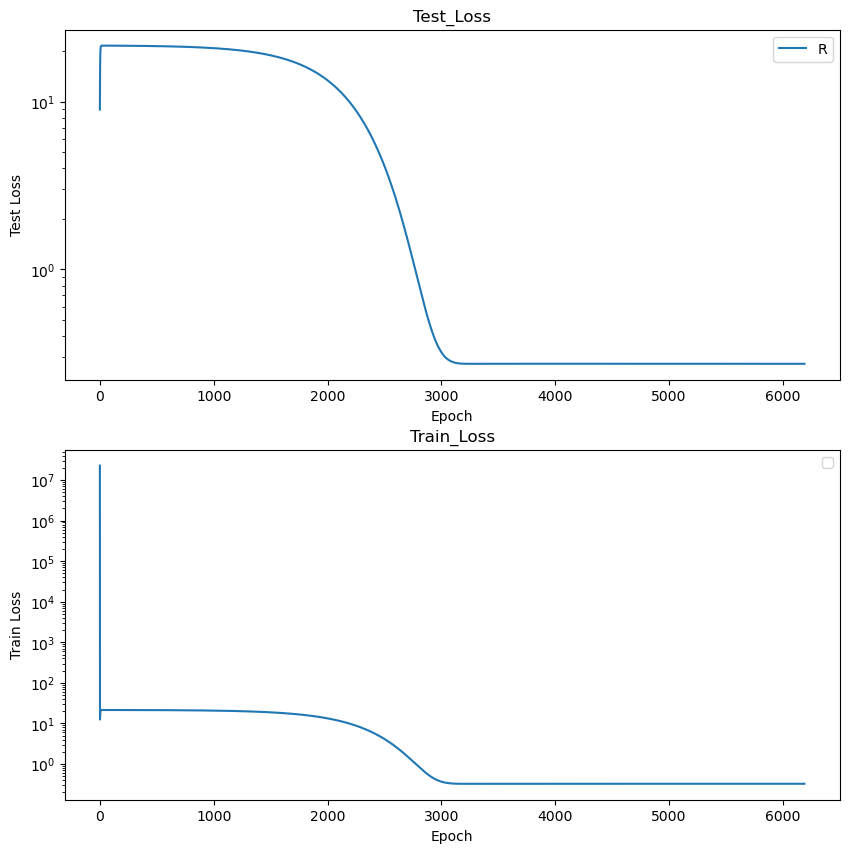

saving work is done
finish--------------------------------------------------------------------------------------------------------------------------------------------------------



No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


act:  ReLU opt:  Adam batch_size:  32 learningRate:  0.01 epoch:  6162 , RMSE_Test: 0.52396 , RMSE_Train: 0.57098 , est_time:   5.0 min, average_time: 0.05 s
start to save model
start to save log
my_results/1695963093_0.52final.pt
, layer_dim_list: [2200, 1000, 100, 10, 1] activateion: ReLU , optimizer: Adam , Bsize: 32 , learningRate: 0.01
, epoch:  6162 , passed_time: 5.000 m , minimum_RMSE: 0.18758 , test_loss: 0.523964 , train_loss: 0.570978 , passed_time_accum: 135.365 m model_save_time 1695963093
start to save figures


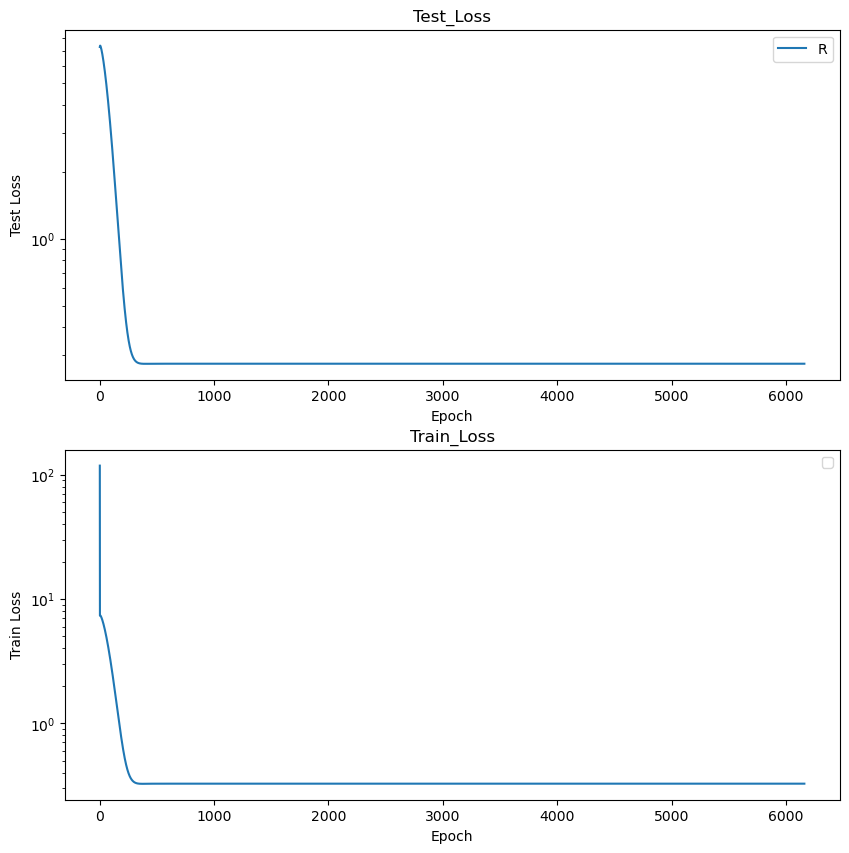

saving work is done
finish--------------------------------------------------------------------------------------------------------------------------------------------------------



No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


act:  ReLU opt:  Adam batch_size:  32 learningRate:  0.05 epoch:  6204 , RMSE_Test: 0.52387 , RMSE_Train: 0.57101 , est_time:   5.0 min, average_time: 0.05 s
start to save model
start to save log
my_results/1695963394_0.52final.pt
, layer_dim_list: [2200, 1000, 100, 10, 1] activateion: ReLU , optimizer: Adam , Bsize: 32 , learningRate: 0.05
, epoch:  6204 , passed_time: 5.001 m , minimum_RMSE: 0.18758 , test_loss: 0.523871 , train_loss: 0.571005 , passed_time_accum: 140.377 m model_save_time 1695963394
start to save figures


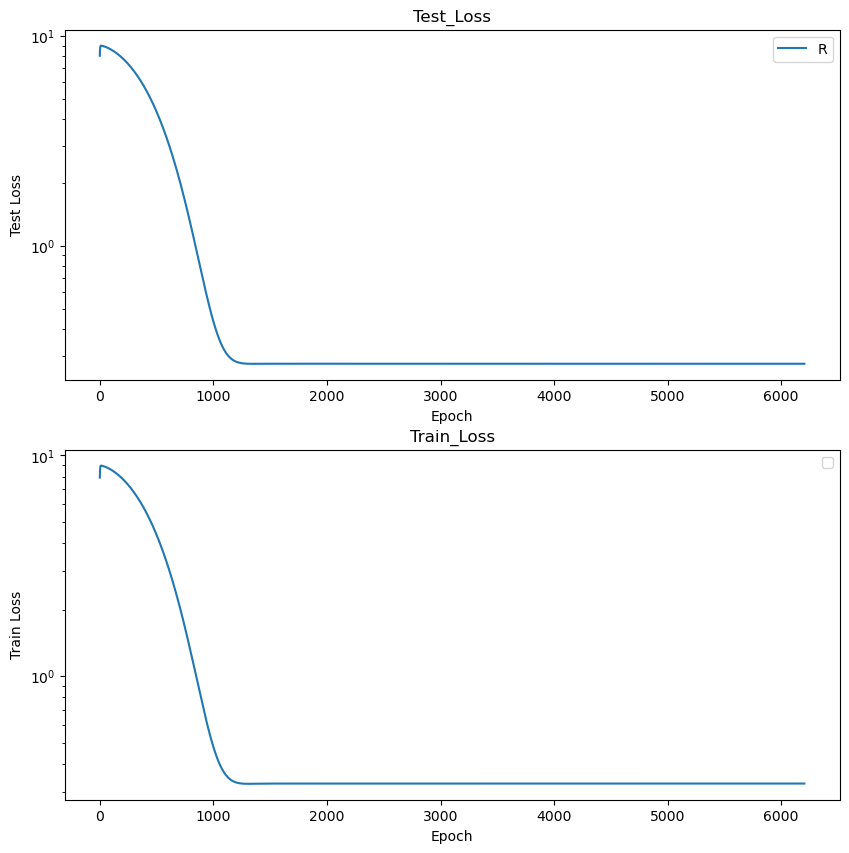

saving work is done
finish--------------------------------------------------------------------------------------------------------------------------------------------------------



No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


act:  ReLU opt:  Adam batch_size:  32 learningRate:  0.001 epoch:  6242 , RMSE_Test: 0.20171 , RMSE_Train: 0.25423 , est_time:   5.0 min, average_time: 0.05 s
start to save model
start to save log
my_results/1695963694_0.20final.pt
, layer_dim_list: [2200, 1000, 100, 10, 1] activateion: ReLU , optimizer: Adam , Bsize: 32 , learningRate: 0.001
, epoch:  6242 , passed_time: 5.000 m , minimum_RMSE: 0.18758 , test_loss: 0.201706 , train_loss: 0.254231 , passed_time_accum: 145.387 m model_save_time 1695963694
start to save figures


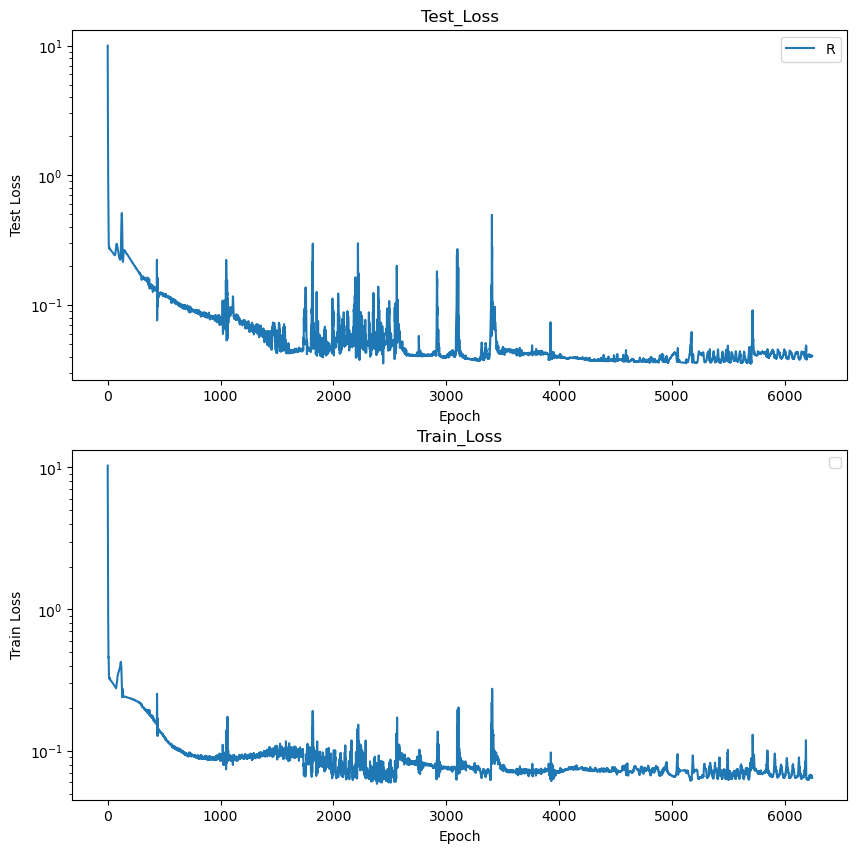

saving work is done
finish--------------------------------------------------------------------------------------------------------------------------------------------------------



No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


act:  ReLU opt:  Adam batch_size:  32 learningRate:  0.005 epoch:  6189 , RMSE_Test: 0.52398 , RMSE_Train: 0.57097 , est_time:   5.0 min, average_time: 0.05 s
start to save model
start to save log
my_results/1695963995_0.52final.pt
, layer_dim_list: [2200, 1000, 100, 10, 1] activateion: ReLU , optimizer: Adam , Bsize: 32 , learningRate: 0.005
, epoch:  6189 , passed_time: 5.000 m , minimum_RMSE: 0.18758 , test_loss: 0.523976 , train_loss: 0.570974 , passed_time_accum: 150.400 m model_save_time 1695963995
start to save figures


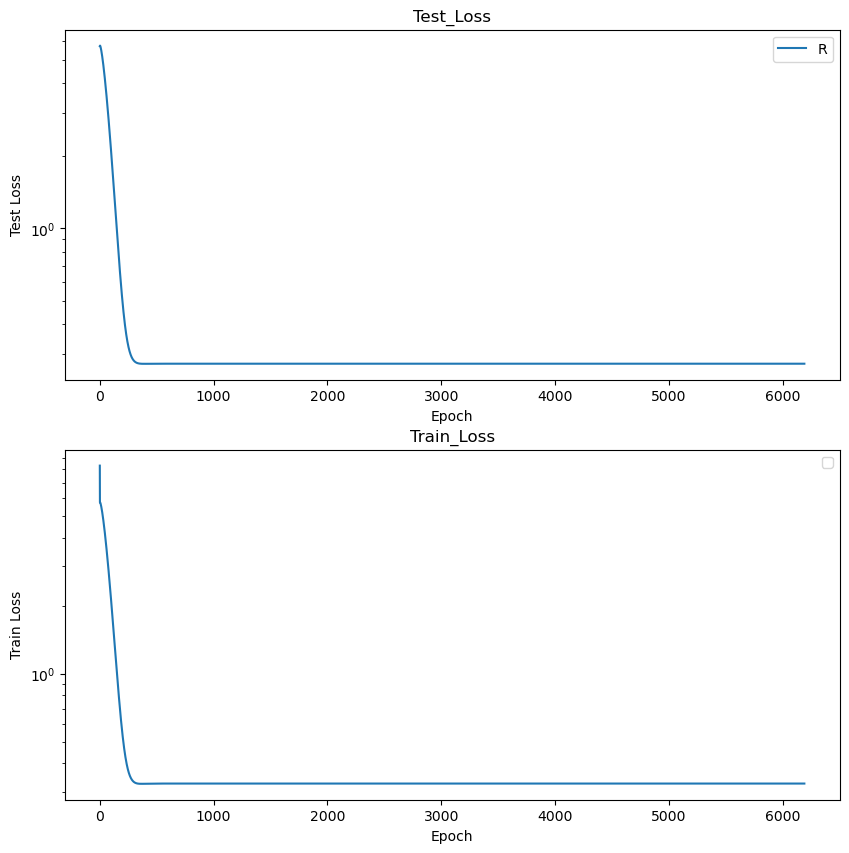

saving work is done
finish--------------------------------------------------------------------------------------------------------------------------------------------------------

act:  ReLU opt:  Adam batch_size:  32 learningRate:  0.0001 epoch:  2011 , RMSE_Test: 0.18697 , RMSE_Train: 0.27789 , est_time:   1.9 min, average_time: 0.06 s
act:  ReLU opt:  Adam batch_size:  32 learningRate:  0.0001 epoch:  2050 , RMSE_Test: 0.18646 , RMSE_Train: 0.27241 , est_time:   2.0 min, average_time: 0.06 s
act:  ReLU opt:  Adam batch_size:  32 learningRate:  0.0001 epoch:  2205 , RMSE_Test: 0.18607 , RMSE_Train: 0.31405 , est_time:   2.1 min, average_time: 0.06 s
act:  ReLU opt:  Adam batch_size:  32 learningRate:  0.0001 epoch:  2221 , RMSE_Test: 0.18448 , RMSE_Train: 0.27531 , est_time:   2.1 min, average_time: 0.06 s
act:  ReLU opt:  Adam batch_size:  32 learningRate:  0.0001 epoch:  2862 , RMSE_Test: 0.18430 , RMSE_Train: 0.27138 , est_time:   2.8 min, average_time: 0.06 s
act:  ReLU opt:  Ada

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


act:  ReLU opt:  Adam batch_size:  32 learningRate:  0.0001 epoch:  5214 , RMSE_Test: 0.21235 , RMSE_Train: 0.23487 , est_time:   5.0 min, average_time: 0.06 s
start to save model
start to save log
my_results/1695964296_0.21final.pt
, layer_dim_list: [2200, 1000, 100, 10, 1] activateion: ReLU , optimizer: Adam , Bsize: 32 , learningRate: 0.0001
, epoch:  5214 , passed_time: 5.001 m , minimum_RMSE: 0.17853 , test_loss: 0.212347 , train_loss: 0.234869 , passed_time_accum: 155.410 m model_save_time 1695964296
start to save figures


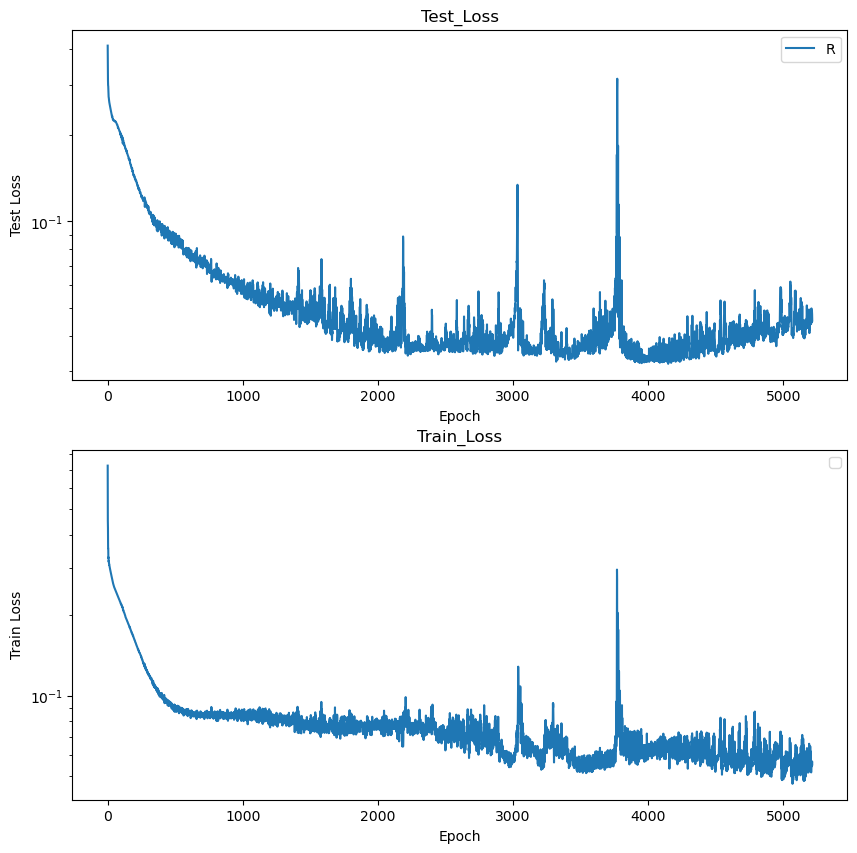

saving work is done
finish--------------------------------------------------------------------------------------------------------------------------------------------------------



No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


act:  ReLU opt:  Adam batch_size:  32 learningRate:  0.0005 epoch:  6166 , RMSE_Test: 0.25506 , RMSE_Train: 0.32411 , est_time:   5.0 min, average_time: 0.05 s
start to save model
start to save log
my_results/1695964597_0.25final.pt
, layer_dim_list: [2200, 1000, 100, 10, 1] activateion: ReLU , optimizer: Adam , Bsize: 32 , learningRate: 0.0005
, epoch:  6166 , passed_time: 5.001 m , minimum_RMSE: 0.17853 , test_loss: 0.255058 , train_loss: 0.324111 , passed_time_accum: 160.425 m model_save_time 1695964597
start to save figures


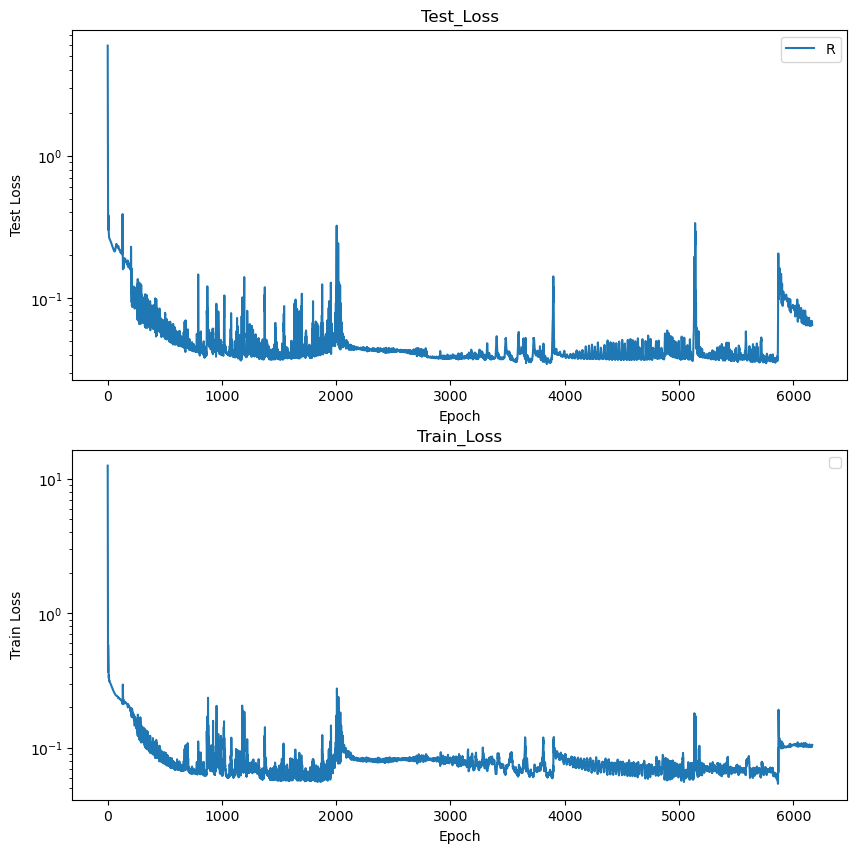

saving work is done
finish--------------------------------------------------------------------------------------------------------------------------------------------------------



No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


act:  ReLU opt:  Adam batch_size:  32 learningRate:  1e-05 epoch:  6203 , RMSE_Test: 0.21565 , RMSE_Train: 0.25722 , est_time:   5.0 min, average_time: 0.05 s
start to save model
start to save log
my_results/1695964897_0.21final.pt
, layer_dim_list: [2200, 1000, 100, 10, 1] activateion: ReLU , optimizer: Adam , Bsize: 32 , learningRate: 1e-05
, epoch:  6203 , passed_time: 5.001 m , minimum_RMSE: 0.17853 , test_loss: 0.215652 , train_loss: 0.257218 , passed_time_accum: 165.437 m model_save_time 1695964897
start to save figures


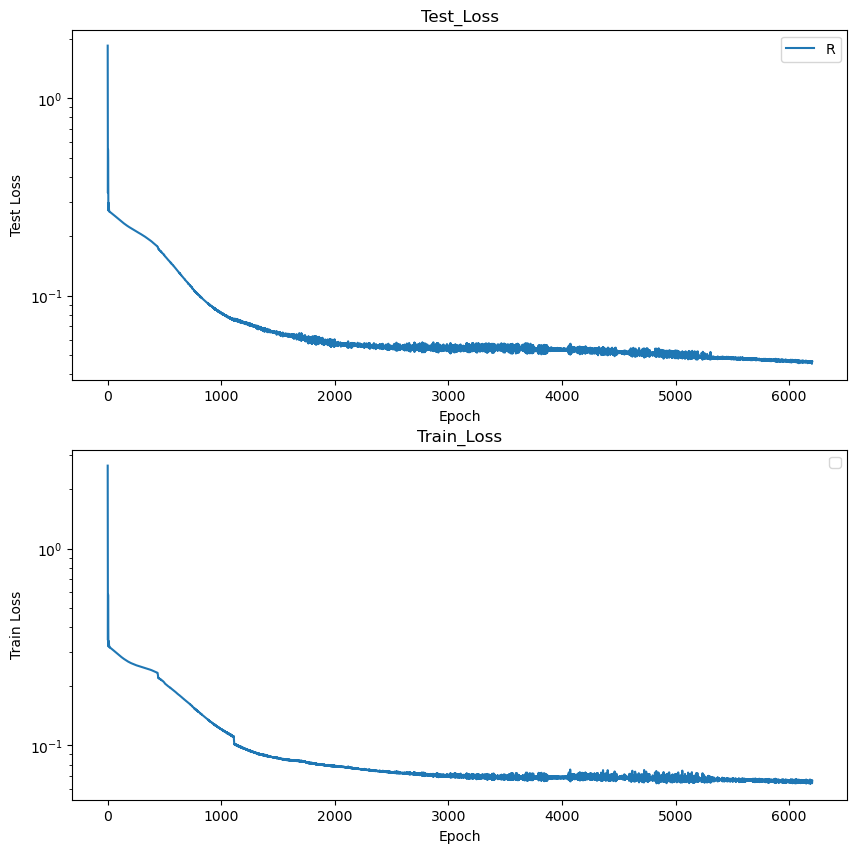

saving work is done
finish--------------------------------------------------------------------------------------------------------------------------------------------------------



No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


act:  ReLU opt:  Adam batch_size:  32 learningRate:  5e-05 epoch:  6186 , RMSE_Test: 0.20647 , RMSE_Train: 0.24514 , est_time:   5.0 min, average_time: 0.05 s
start to save model
start to save log
my_results/1695965198_0.20final.pt
, layer_dim_list: [2200, 1000, 100, 10, 1] activateion: ReLU , optimizer: Adam , Bsize: 32 , learningRate: 5e-05
, epoch:  6186 , passed_time: 5.001 m , minimum_RMSE: 0.17853 , test_loss: 0.206468 , train_loss: 0.245144 , passed_time_accum: 170.449 m model_save_time 1695965198
start to save figures


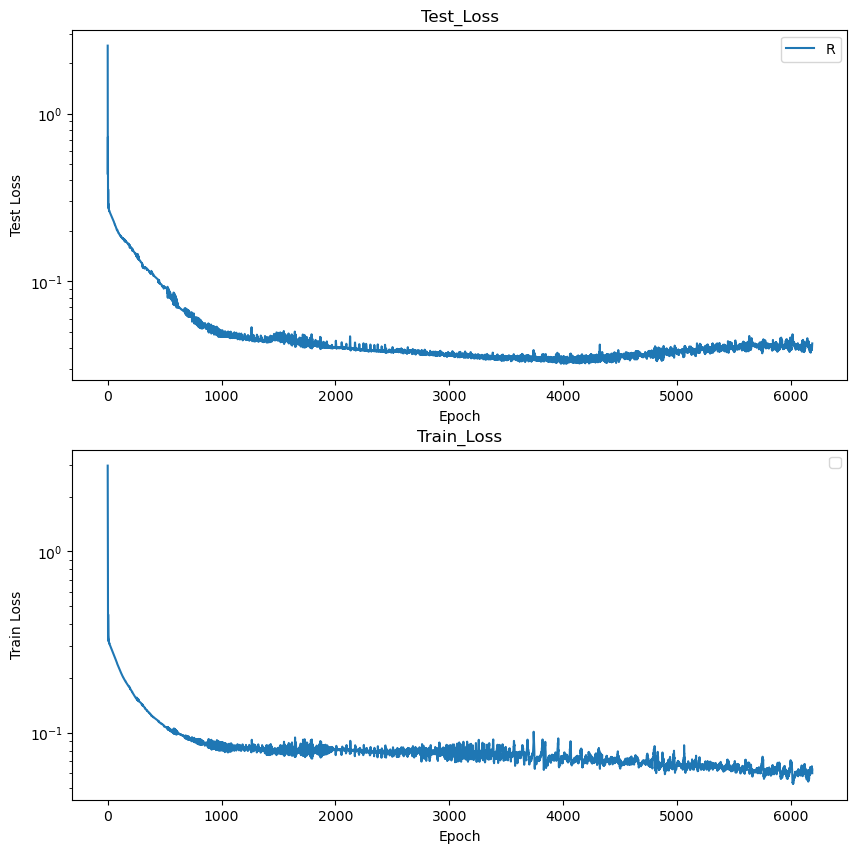

saving work is done
finish--------------------------------------------------------------------------------------------------------------------------------------------------------



No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


act:  ReLU opt:  Adam batch_size:  32 learningRate:  1e-06 epoch:  6217 , RMSE_Test: 0.26489 , RMSE_Train: 0.31284 , est_time:   5.0 min, average_time: 0.05 s
start to save model
start to save log
my_results/1695965499_0.26final.pt
, layer_dim_list: [2200, 1000, 100, 10, 1] activateion: ReLU , optimizer: Adam , Bsize: 32 , learningRate: 1e-06
, epoch:  6217 , passed_time: 5.001 m , minimum_RMSE: 0.17853 , test_loss: 0.264892 , train_loss: 0.312844 , passed_time_accum: 175.460 m model_save_time 1695965499
start to save figures


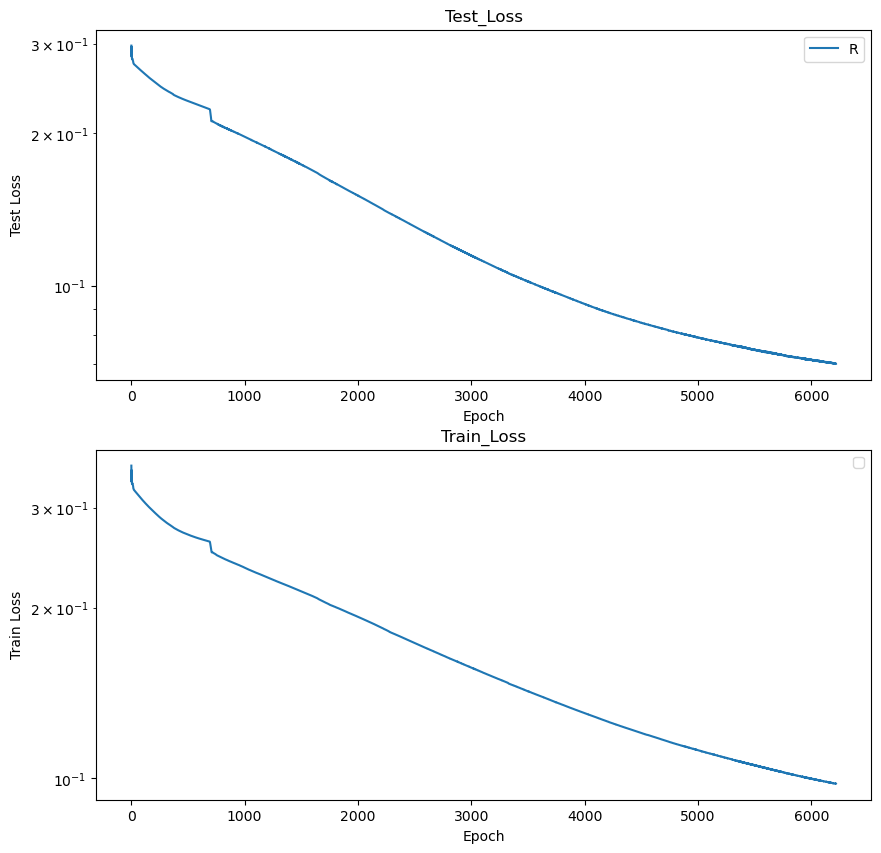

saving work is done
finish--------------------------------------------------------------------------------------------------------------------------------------------------------



No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


act:  ReLU opt:  Adam batch_size:  32 learningRate:  5e-06 epoch:  2390 , RMSE_Test: 0.24840 , RMSE_Train: 0.28224 , est_time:   5.0 min, average_time: 0.13 s
start to save model
start to save log
my_results/1695965799_0.24final.pt
, layer_dim_list: [2200, 1000, 100, 10, 1] activateion: ReLU , optimizer: Adam , Bsize: 32 , learningRate: 5e-06
, epoch:  2390 , passed_time: 5.001 m , minimum_RMSE: 0.17853 , test_loss: 0.248401 , train_loss: 0.282239 , passed_time_accum: 180.472 m model_save_time 1695965799
start to save figures


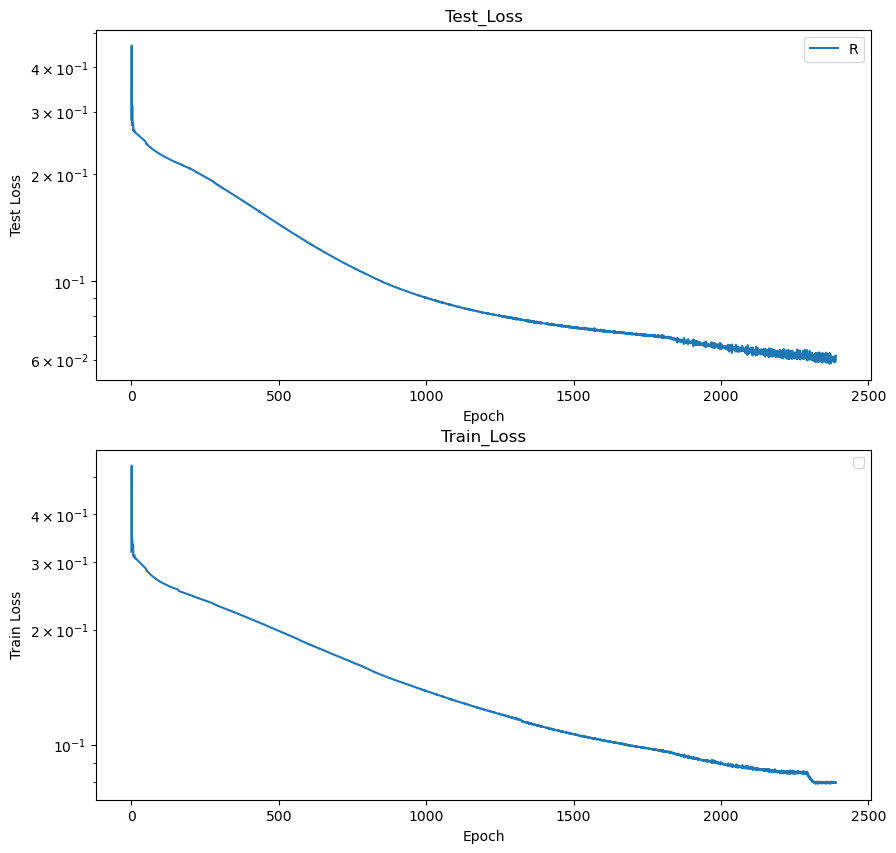

saving work is done
finish--------------------------------------------------------------------------------------------------------------------------------------------------------



No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


act:  ReLU opt:  Adam batch_size:  64 learningRate:  0.1 epoch:  3754 , RMSE_Test: 0.52382 , RMSE_Train: 0.57066 , est_time:   5.0 min, average_time: 0.08 s
start to save model
start to save log
my_results/1695966100_0.52final.pt
, layer_dim_list: [2200, 1000, 100, 10, 1] activateion: ReLU , optimizer: Adam , Bsize: 64 , learningRate: 0.1
, epoch:  3754 , passed_time: 5.001 m , minimum_RMSE: 0.17853 , test_loss: 0.523816 , train_loss: 0.570663 , passed_time_accum: 185.483 m model_save_time 1695966100
start to save figures


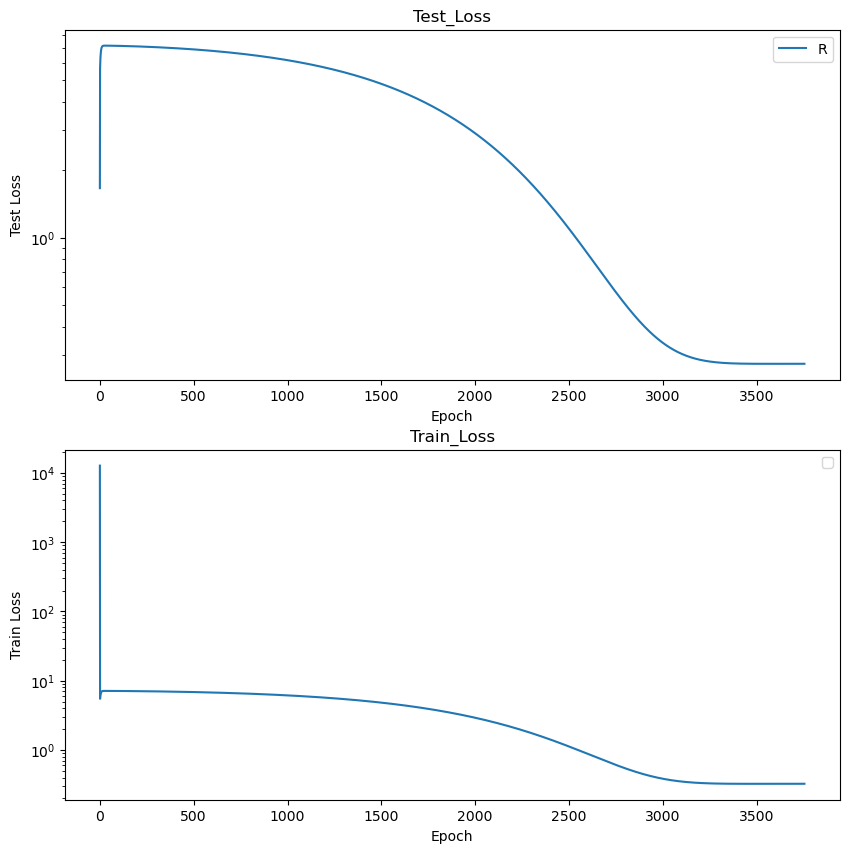

saving work is done
finish--------------------------------------------------------------------------------------------------------------------------------------------------------



No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


act:  ReLU opt:  Adam batch_size:  64 learningRate:  0.5 epoch:  3986 , RMSE_Test: 3.81366 , RMSE_Train: 3.80838 , est_time:   5.0 min, average_time: 0.08 s
start to save model
start to save log
my_results/1695966401_3final.pt
, layer_dim_list: [2200, 1000, 100, 10, 1] activateion: ReLU , optimizer: Adam , Bsize: 64 , learningRate: 0.5
, epoch:  3986 , passed_time: 5.001 m , minimum_RMSE: 0.17853 , test_loss: 3.813663 , train_loss: 3.808382 , passed_time_accum: 190.497 m model_save_time 1695966401
start to save figures


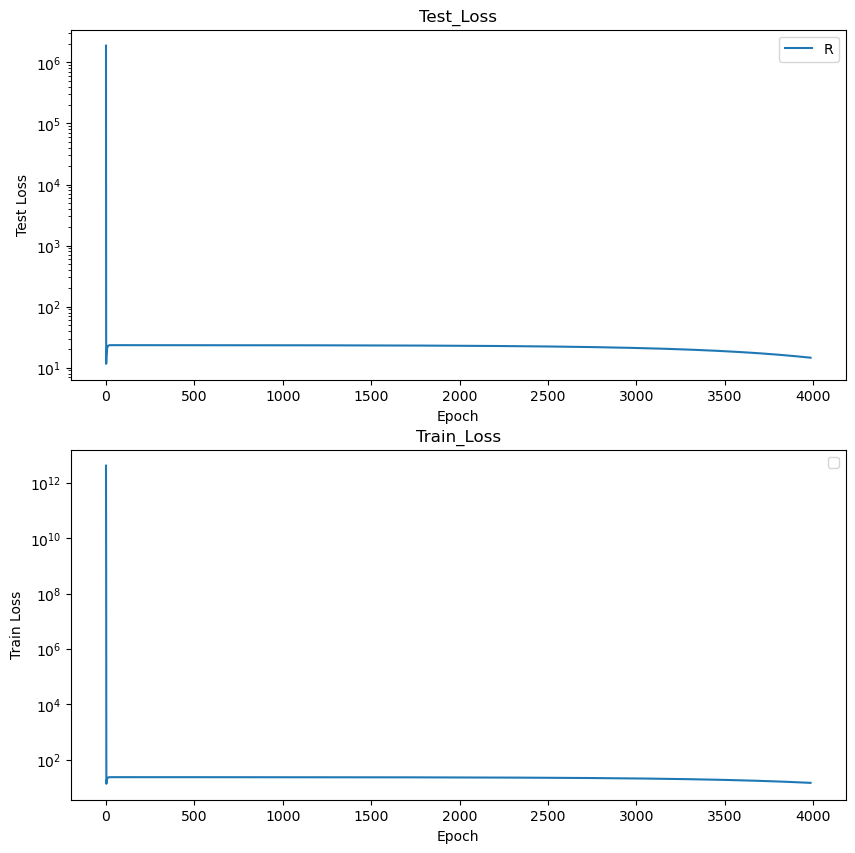

saving work is done
finish--------------------------------------------------------------------------------------------------------------------------------------------------------



No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


act:  ReLU opt:  Adam batch_size:  64 learningRate:  0.01 epoch:  3571 , RMSE_Test: 0.52383 , RMSE_Train: 0.57079 , est_time:   5.0 min, average_time: 0.08 s
start to save model
start to save log
my_results/1695966702_0.52final.pt
, layer_dim_list: [2200, 1000, 100, 10, 1] activateion: ReLU , optimizer: Adam , Bsize: 64 , learningRate: 0.01
, epoch:  3571 , passed_time: 5.001 m , minimum_RMSE: 0.17853 , test_loss: 0.523826 , train_loss: 0.570793 , passed_time_accum: 195.511 m model_save_time 1695966702
start to save figures


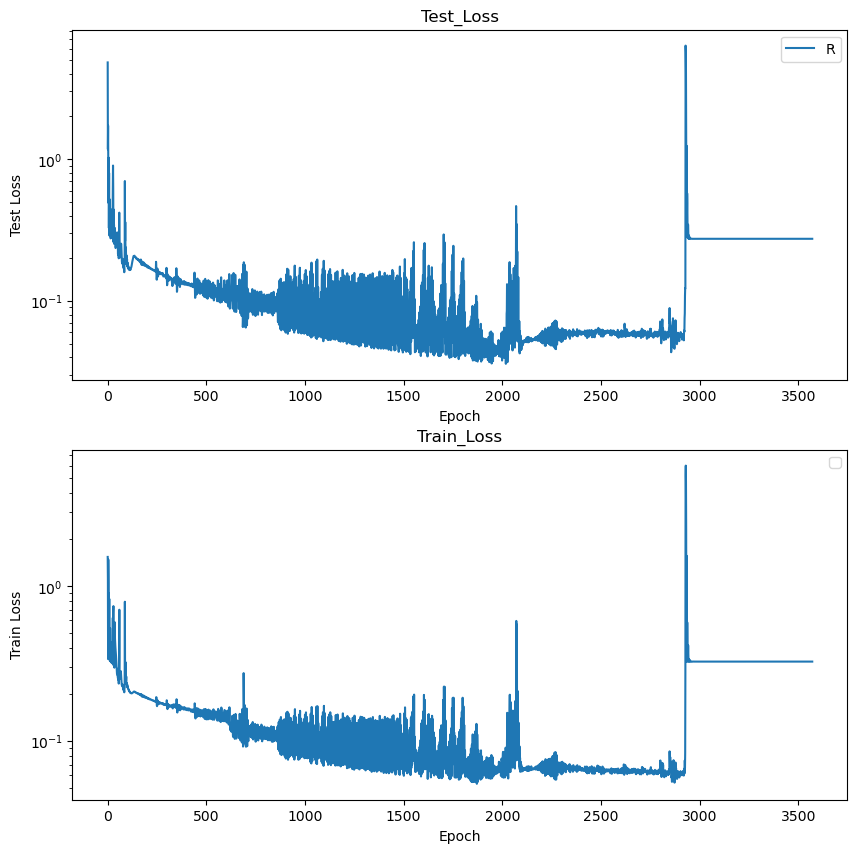

saving work is done
finish--------------------------------------------------------------------------------------------------------------------------------------------------------



No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


act:  ReLU opt:  Adam batch_size:  64 learningRate:  0.05 epoch:  3949 , RMSE_Test: 0.52383 , RMSE_Train: 0.57080 , est_time:   5.0 min, average_time: 0.08 s
start to save model
start to save log
my_results/1695967002_0.52final.pt
, layer_dim_list: [2200, 1000, 100, 10, 1] activateion: ReLU , optimizer: Adam , Bsize: 64 , learningRate: 0.05
, epoch:  3949 , passed_time: 5.000 m , minimum_RMSE: 0.17853 , test_loss: 0.523825 , train_loss: 0.570799 , passed_time_accum: 200.523 m model_save_time 1695967002
start to save figures


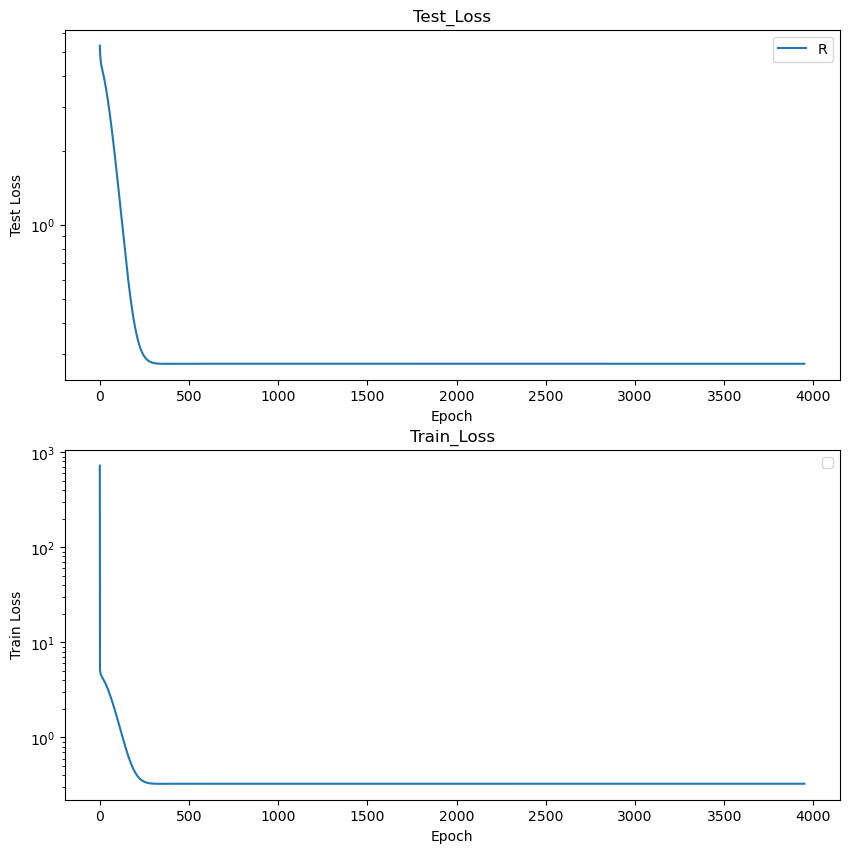

saving work is done
finish--------------------------------------------------------------------------------------------------------------------------------------------------------



No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


act:  ReLU opt:  Adam batch_size:  64 learningRate:  0.001 epoch:  9677 , RMSE_Test: 0.28199 , RMSE_Train: 0.31112 , est_time:   5.0 min, average_time: 0.03 s
start to save model
start to save log
my_results/1695967303_0.28final.pt
, layer_dim_list: [2200, 1000, 100, 10, 1] activateion: ReLU , optimizer: Adam , Bsize: 64 , learningRate: 0.001
, epoch:  9677 , passed_time: 5.000 m , minimum_RMSE: 0.17853 , test_loss: 0.281991 , train_loss: 0.311119 , passed_time_accum: 205.539 m model_save_time 1695967303
start to save figures


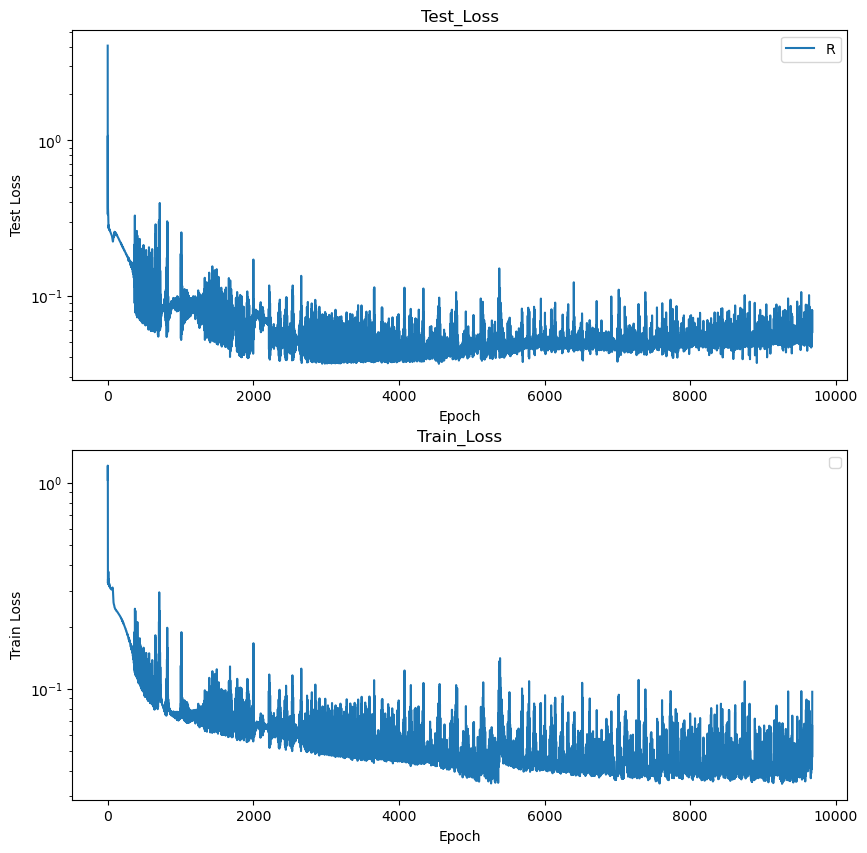

saving work is done
finish--------------------------------------------------------------------------------------------------------------------------------------------------------



No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


act:  ReLU opt:  Adam batch_size:  64 learningRate:  0.005 epoch:  9672 , RMSE_Test: 0.52385 , RMSE_Train: 0.57075 , est_time:   5.0 min, average_time: 0.03 s
start to save model
start to save log
my_results/1695967604_0.52final.pt
, layer_dim_list: [2200, 1000, 100, 10, 1] activateion: ReLU , optimizer: Adam , Bsize: 64 , learningRate: 0.005
, epoch:  9672 , passed_time: 5.001 m , minimum_RMSE: 0.17853 , test_loss: 0.523850 , train_loss: 0.570749 , passed_time_accum: 210.551 m model_save_time 1695967604
start to save figures


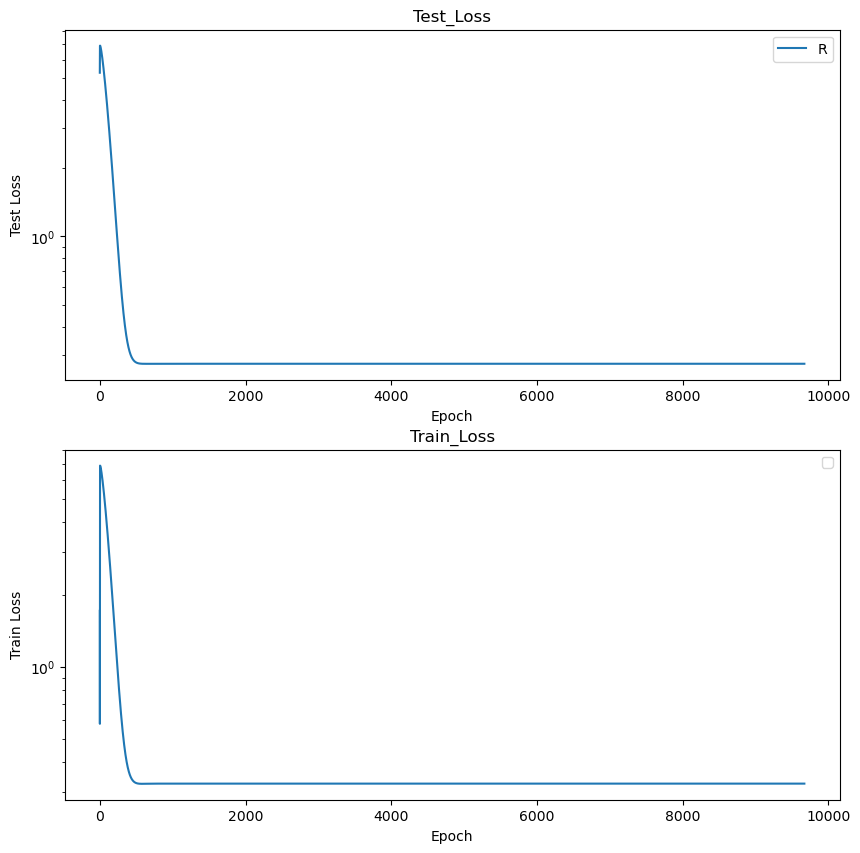

saving work is done
finish--------------------------------------------------------------------------------------------------------------------------------------------------------



No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


act:  ReLU opt:  Adam batch_size:  64 learningRate:  0.0001 epoch:  9748 , RMSE_Test: 0.22704 , RMSE_Train: 0.17809 , est_time:   5.0 min, average_time: 0.03 s
start to save model
start to save log
my_results/1695967905_0.22final.pt
, layer_dim_list: [2200, 1000, 100, 10, 1] activateion: ReLU , optimizer: Adam , Bsize: 64 , learningRate: 0.0001
, epoch:  9748 , passed_time: 5.000 m , minimum_RMSE: 0.17853 , test_loss: 0.227037 , train_loss: 0.178086 , passed_time_accum: 215.561 m model_save_time 1695967905
start to save figures


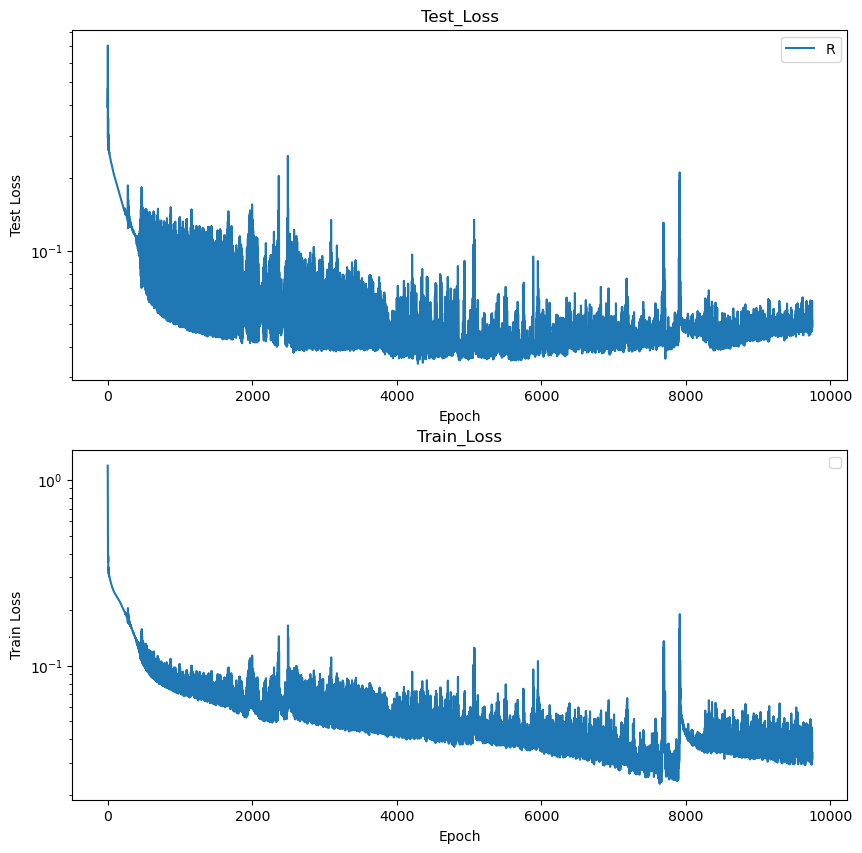

saving work is done
finish--------------------------------------------------------------------------------------------------------------------------------------------------------



No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


act:  ReLU opt:  Adam batch_size:  64 learningRate:  0.0005 epoch:  9730 , RMSE_Test: 0.25241 , RMSE_Train: 0.19597 , est_time:   5.0 min, average_time: 0.03 s
start to save model
start to save log
my_results/1695968206_0.25final.pt
, layer_dim_list: [2200, 1000, 100, 10, 1] activateion: ReLU , optimizer: Adam , Bsize: 64 , learningRate: 0.0005
, epoch:  9730 , passed_time: 5.000 m , minimum_RMSE: 0.17853 , test_loss: 0.252410 , train_loss: 0.195974 , passed_time_accum: 220.573 m model_save_time 1695968206
start to save figures


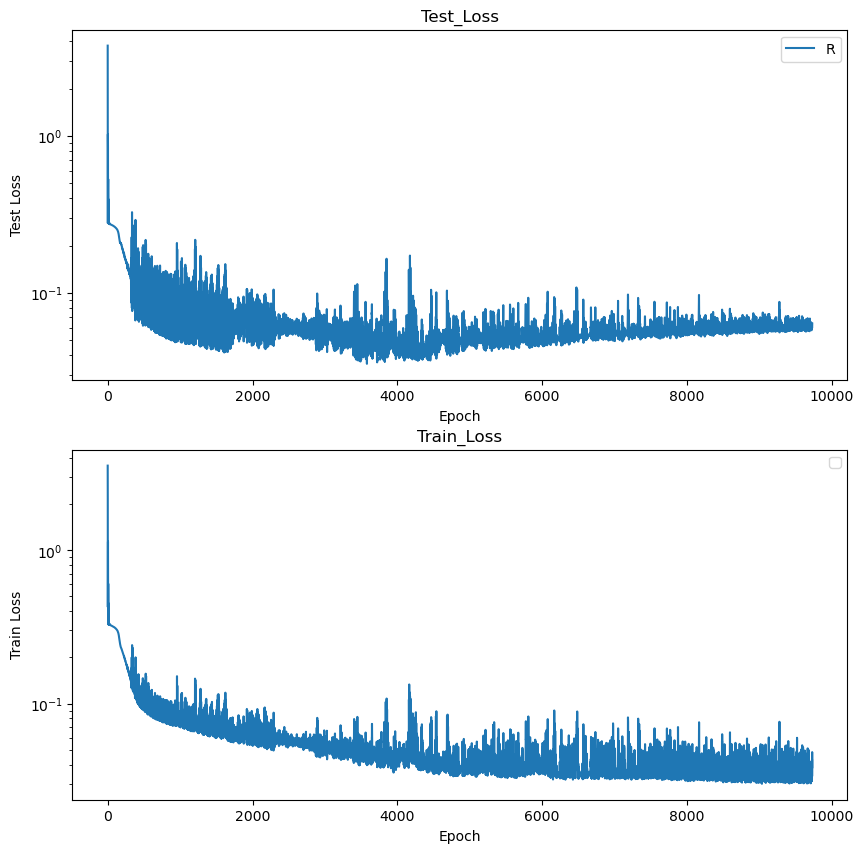

saving work is done
finish--------------------------------------------------------------------------------------------------------------------------------------------------------



No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


act:  ReLU opt:  Adam batch_size:  64 learningRate:  1e-05 epoch:  9683 , RMSE_Test: 0.21513 , RMSE_Train: 0.22136 , est_time:   5.0 min, average_time: 0.03 s
start to save model
start to save log
my_results/1695968506_0.21final.pt
, layer_dim_list: [2200, 1000, 100, 10, 1] activateion: ReLU , optimizer: Adam , Bsize: 64 , learningRate: 1e-05
, epoch:  9683 , passed_time: 5.000 m , minimum_RMSE: 0.17853 , test_loss: 0.215131 , train_loss: 0.221356 , passed_time_accum: 225.585 m model_save_time 1695968506
start to save figures


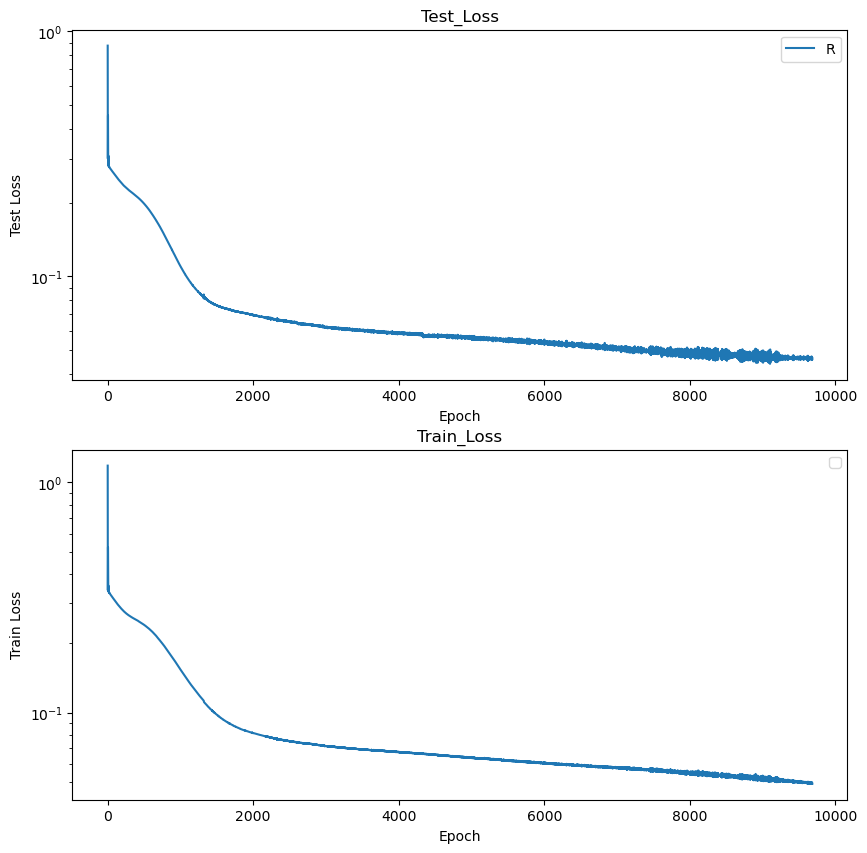

saving work is done
finish--------------------------------------------------------------------------------------------------------------------------------------------------------



No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


act:  ReLU opt:  Adam batch_size:  64 learningRate:  5e-05 epoch:  9776 , RMSE_Test: 0.23078 , RMSE_Train: 0.16010 , est_time:   5.0 min, average_time: 0.03 s
start to save model
start to save log
my_results/1695968807_0.23final.pt
, layer_dim_list: [2200, 1000, 100, 10, 1] activateion: ReLU , optimizer: Adam , Bsize: 64 , learningRate: 5e-05
, epoch:  9776 , passed_time: 5.000 m , minimum_RMSE: 0.17853 , test_loss: 0.230778 , train_loss: 0.160097 , passed_time_accum: 230.596 m model_save_time 1695968807
start to save figures


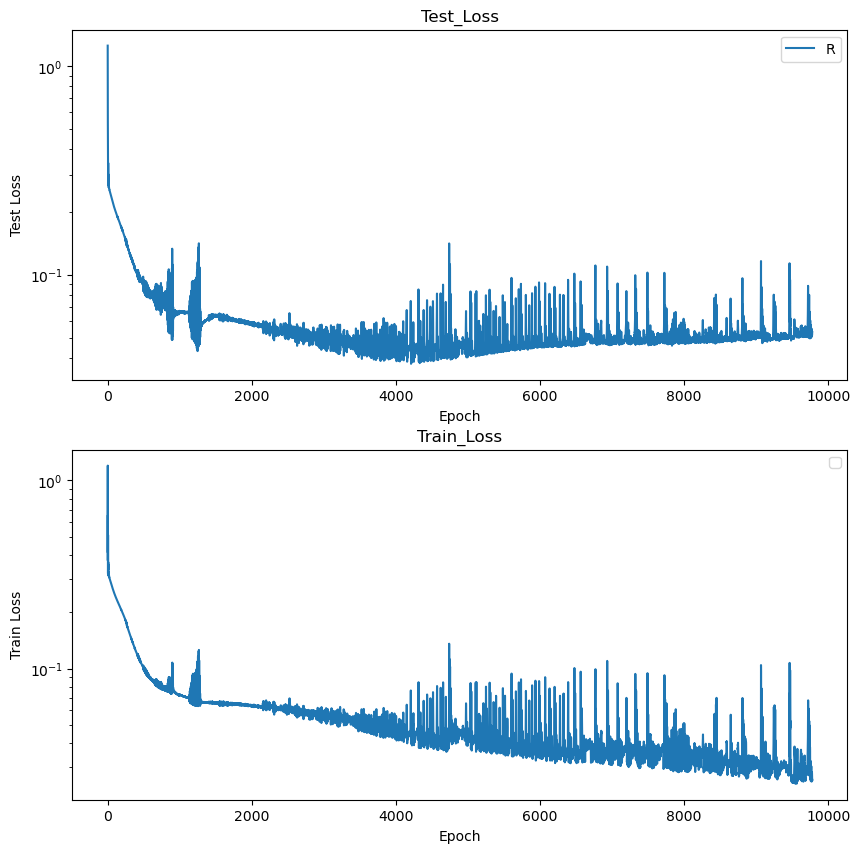

saving work is done
finish--------------------------------------------------------------------------------------------------------------------------------------------------------



No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


act:  ReLU opt:  Adam batch_size:  64 learningRate:  1e-06 epoch:  9746 , RMSE_Test: 2.24287 , RMSE_Train: 2.24205 , est_time:   5.0 min, average_time: 0.03 s
start to save model
start to save log
my_results/1695969108_2final.pt
, layer_dim_list: [2200, 1000, 100, 10, 1] activateion: ReLU , optimizer: Adam , Bsize: 64 , learningRate: 1e-06
, epoch:  9746 , passed_time: 5.001 m , minimum_RMSE: 0.17853 , test_loss: 2.242868 , train_loss: 2.242054 , passed_time_accum: 235.608 m model_save_time 1695969108
start to save figures


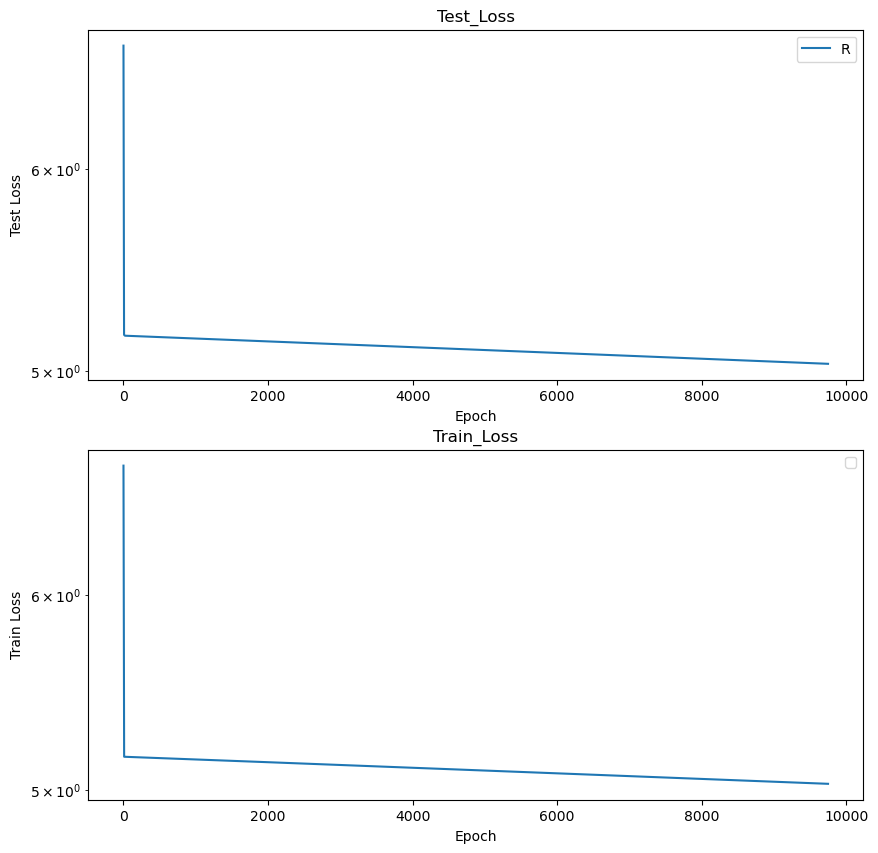

saving work is done
finish--------------------------------------------------------------------------------------------------------------------------------------------------------



No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


act:  ReLU opt:  Adam batch_size:  64 learningRate:  5e-06 epoch:  9651 , RMSE_Test: 0.22611 , RMSE_Train: 0.23822 , est_time:   5.0 min, average_time: 0.03 s
start to save model
start to save log
my_results/1695969408_0.22final.pt
, layer_dim_list: [2200, 1000, 100, 10, 1] activateion: ReLU , optimizer: Adam , Bsize: 64 , learningRate: 5e-06
, epoch:  9651 , passed_time: 5.000 m , minimum_RMSE: 0.17853 , test_loss: 0.226106 , train_loss: 0.238224 , passed_time_accum: 240.616 m model_save_time 1695969408
start to save figures


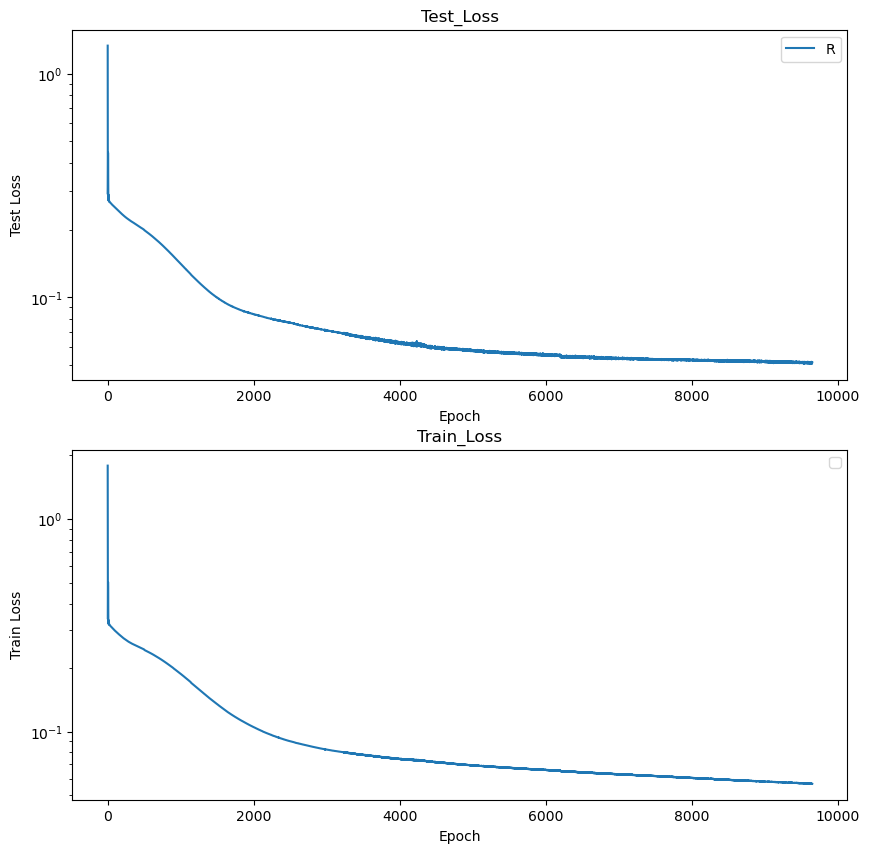

saving work is done
finish--------------------------------------------------------------------------------------------------------------------------------------------------------



No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


act:  ReLU opt:  Adam batch_size:  128 learningRate:  0.1 epoch:  5546 , RMSE_Test: 0.52383 , RMSE_Train: 0.57126 , est_time:   5.0 min, average_time: 0.05 s
start to save model
start to save log
my_results/1695969709_0.52final.pt
, layer_dim_list: [2200, 1000, 100, 10, 1] activateion: ReLU , optimizer: Adam , Bsize: 128 , learningRate: 0.1
, epoch:  5546 , passed_time: 5.000 m , minimum_RMSE: 0.17853 , test_loss: 0.523825 , train_loss: 0.571257 , passed_time_accum: 245.627 m model_save_time 1695969709
start to save figures


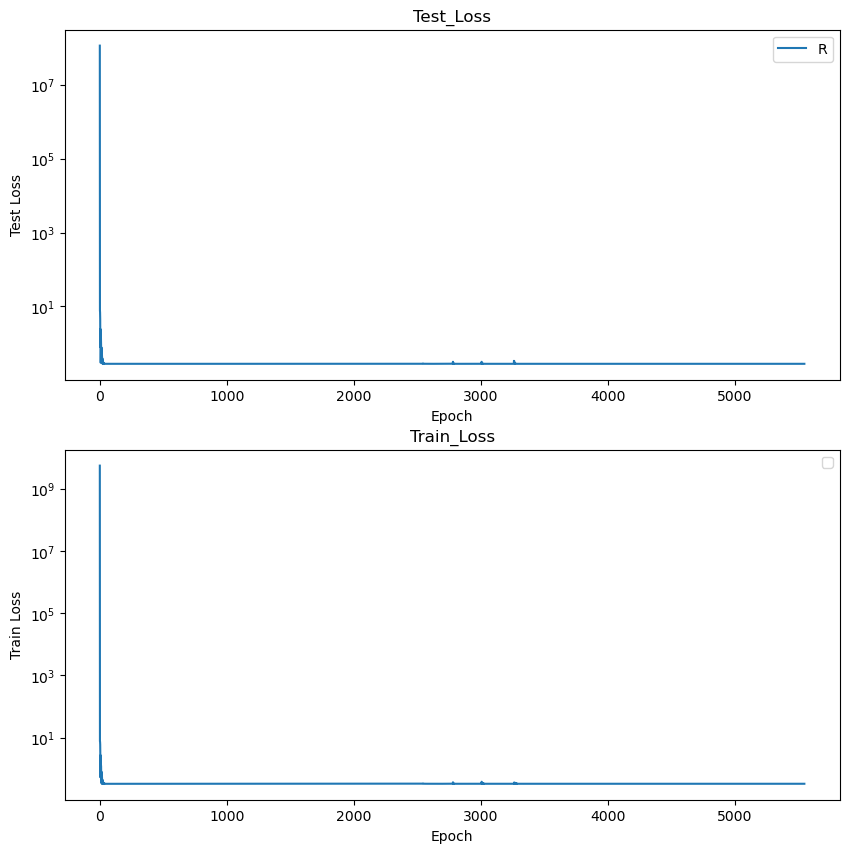

saving work is done
finish--------------------------------------------------------------------------------------------------------------------------------------------------------



No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


act:  ReLU opt:  Adam batch_size:  128 learningRate:  0.5 epoch:  5567 , RMSE_Test: 4.14669 , RMSE_Train: 4.14065 , est_time:   5.0 min, average_time: 0.05 s
start to save model
start to save log
my_results/1695970009_4final.pt
, layer_dim_list: [2200, 1000, 100, 10, 1] activateion: ReLU , optimizer: Adam , Bsize: 128 , learningRate: 0.5
, epoch:  5567 , passed_time: 5.001 m , minimum_RMSE: 0.17853 , test_loss: 4.146687 , train_loss: 4.140648 , passed_time_accum: 250.635 m model_save_time 1695970009
start to save figures


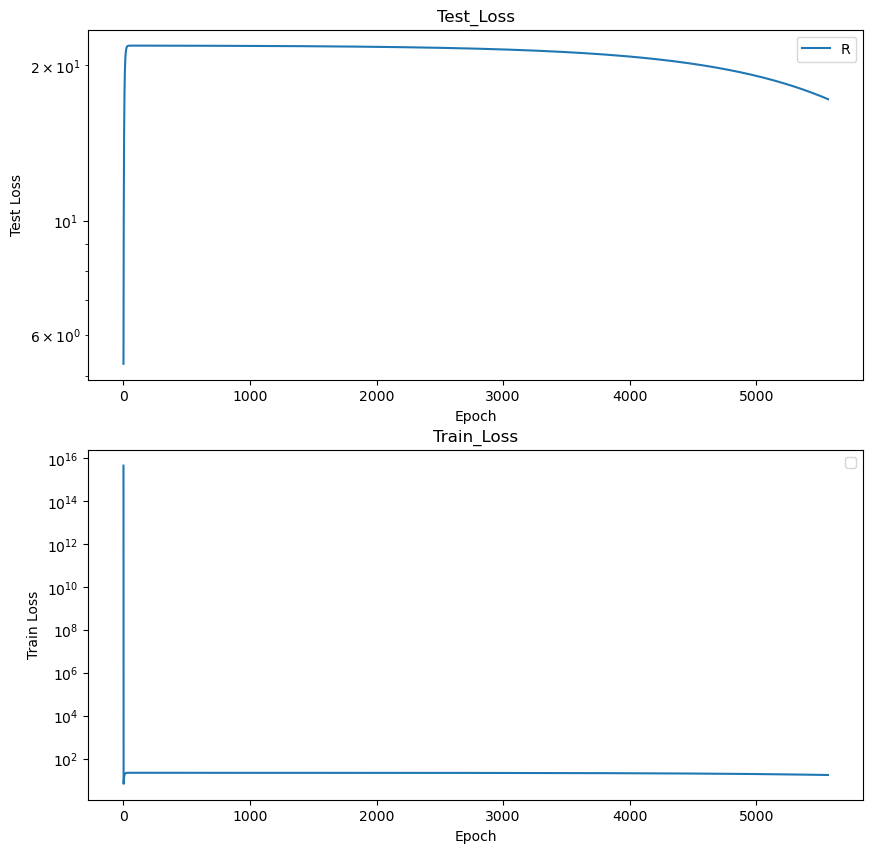

saving work is done
finish--------------------------------------------------------------------------------------------------------------------------------------------------------



No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


act:  ReLU opt:  Adam batch_size:  128 learningRate:  0.01 epoch: 12758 , RMSE_Test: 0.52375 , RMSE_Train: 0.57052 , est_time:   5.0 min, average_time: 0.02 s
start to save model
start to save log
my_results/1695970310_0.52final.pt
, layer_dim_list: [2200, 1000, 100, 10, 1] activateion: ReLU , optimizer: Adam , Bsize: 128 , learningRate: 0.01
, epoch: 12758 , passed_time: 5.000 m , minimum_RMSE: 0.17853 , test_loss: 0.523748 , train_loss: 0.570519 , passed_time_accum: 255.651 m model_save_time 1695970310
start to save figures


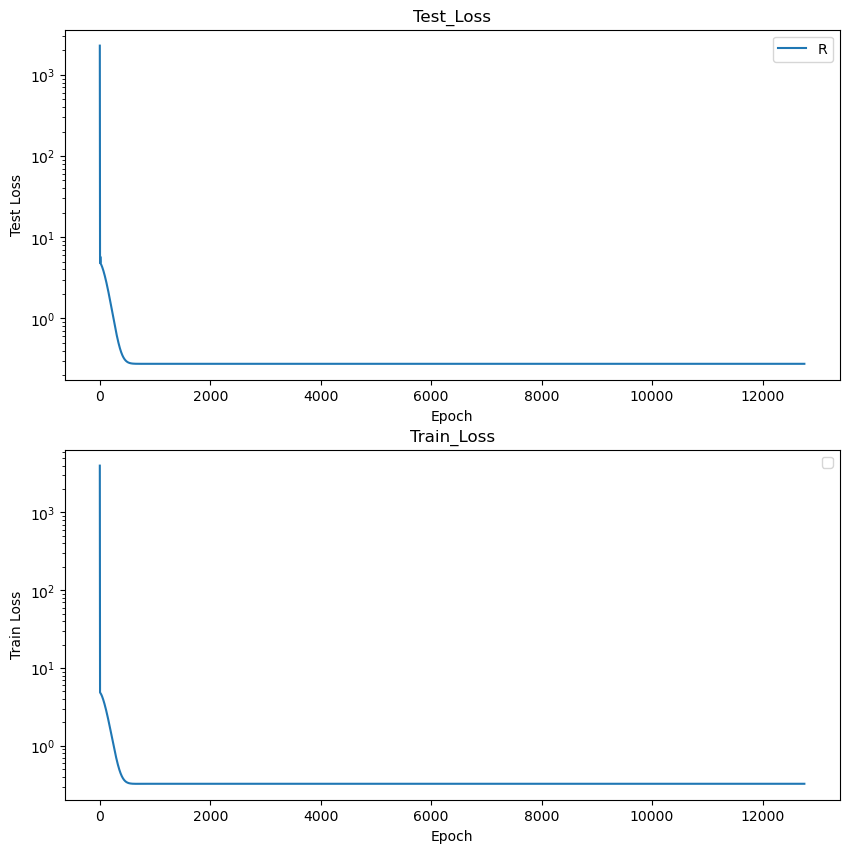

saving work is done
finish--------------------------------------------------------------------------------------------------------------------------------------------------------



No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


act:  ReLU opt:  Adam batch_size:  128 learningRate:  0.05 epoch: 13239 , RMSE_Test: 0.52374 , RMSE_Train: 0.57055 , est_time:   5.0 min, average_time: 0.02 s
start to save model
start to save log
my_results/1695970611_0.52final.pt
, layer_dim_list: [2200, 1000, 100, 10, 1] activateion: ReLU , optimizer: Adam , Bsize: 128 , learningRate: 0.05
, epoch: 13239 , passed_time: 5.000 m , minimum_RMSE: 0.17853 , test_loss: 0.523738 , train_loss: 0.570554 , passed_time_accum: 260.666 m model_save_time 1695970611
start to save figures


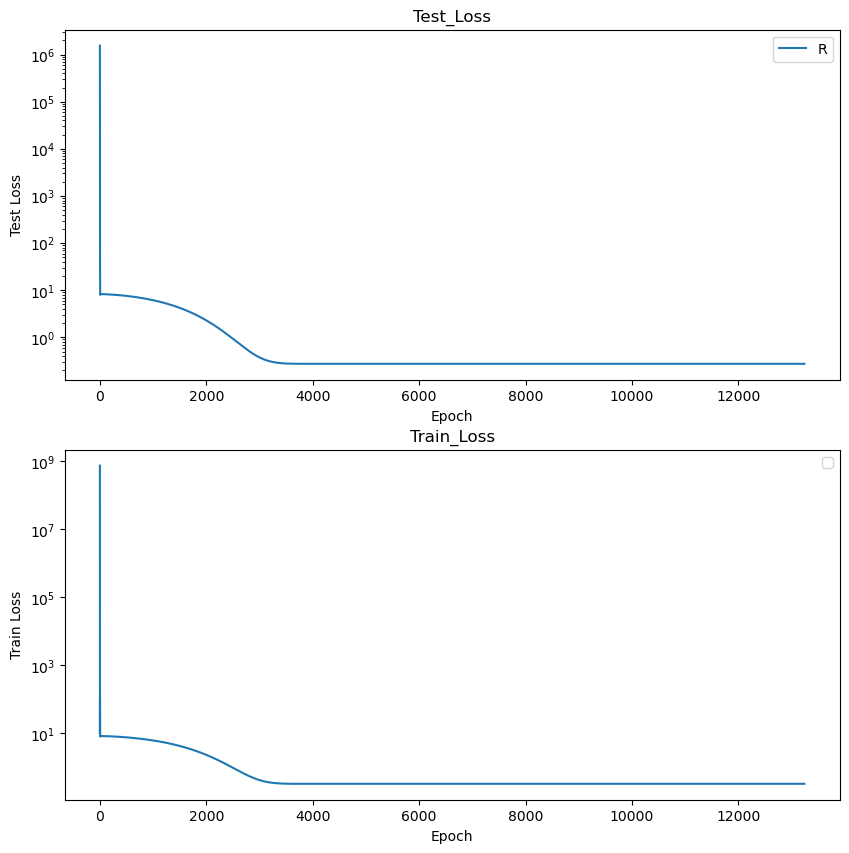

saving work is done
finish--------------------------------------------------------------------------------------------------------------------------------------------------------



No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


act:  ReLU opt:  Adam batch_size:  128 learningRate:  0.001 epoch: 13365 , RMSE_Test: 0.26526 , RMSE_Train: 0.16377 , est_time:   5.0 min, average_time: 0.02 s
start to save model
start to save log
my_results/1695970912_0.26final.pt
, layer_dim_list: [2200, 1000, 100, 10, 1] activateion: ReLU , optimizer: Adam , Bsize: 128 , learningRate: 0.001
, epoch: 13365 , passed_time: 5.000 m , minimum_RMSE: 0.17853 , test_loss: 0.265258 , train_loss: 0.163767 , passed_time_accum: 265.680 m model_save_time 1695970912
start to save figures


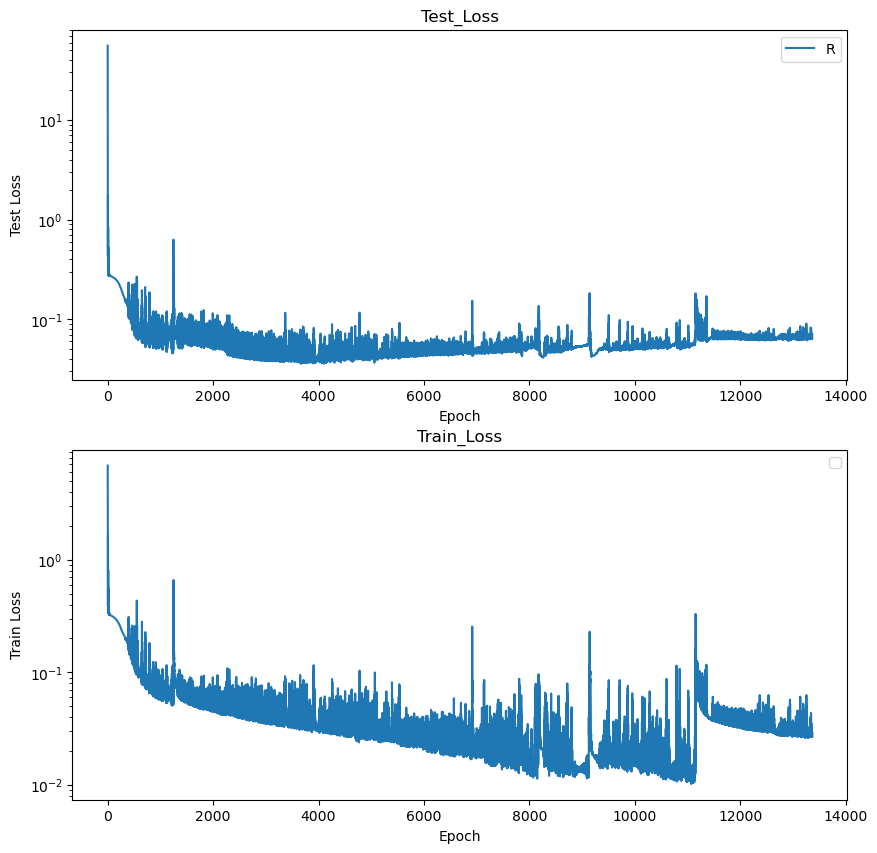

saving work is done
finish--------------------------------------------------------------------------------------------------------------------------------------------------------



No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


act:  ReLU opt:  Adam batch_size:  128 learningRate:  0.005 epoch: 13324 , RMSE_Test: 0.26985 , RMSE_Train: 0.20977 , est_time:   5.0 min, average_time: 0.02 s
start to save model
start to save log
my_results/1695971213_0.26final.pt
, layer_dim_list: [2200, 1000, 100, 10, 1] activateion: ReLU , optimizer: Adam , Bsize: 128 , learningRate: 0.005
, epoch: 13324 , passed_time: 5.001 m , minimum_RMSE: 0.17853 , test_loss: 0.269845 , train_loss: 0.209770 , passed_time_accum: 270.695 m model_save_time 1695971213
start to save figures


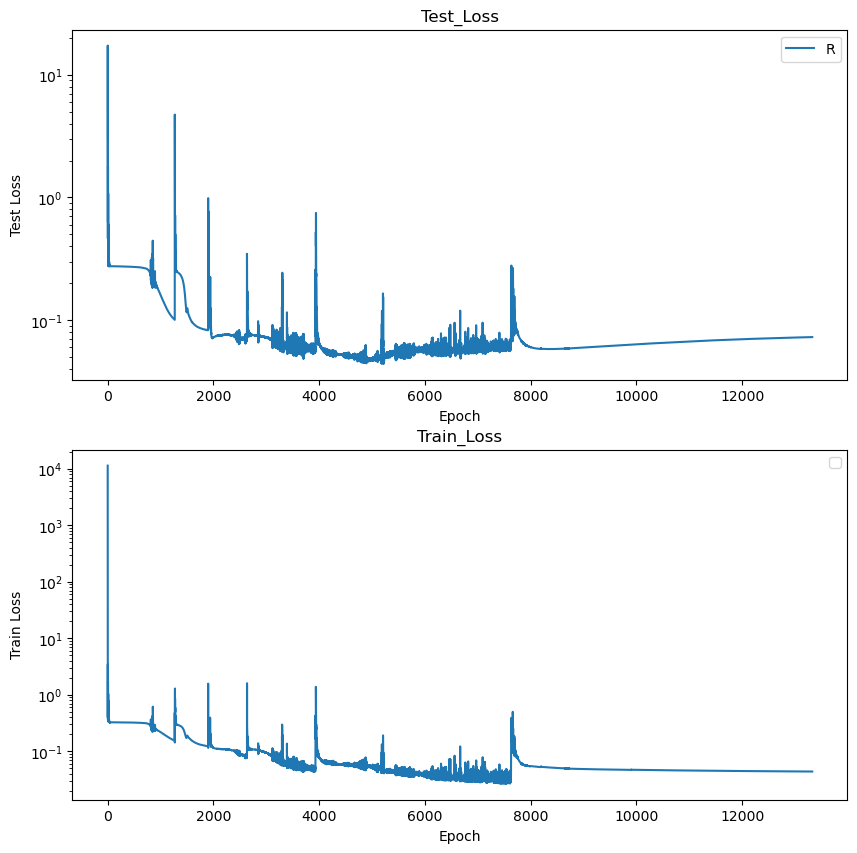

saving work is done
finish--------------------------------------------------------------------------------------------------------------------------------------------------------



No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


act:  ReLU opt:  Adam batch_size:  128 learningRate:  0.0001 epoch: 13377 , RMSE_Test: 0.26790 , RMSE_Train: 0.11148 , est_time:   5.0 min, average_time: 0.02 s
start to save model
start to save log
my_results/1695971514_0.26final.pt
, layer_dim_list: [2200, 1000, 100, 10, 1] activateion: ReLU , optimizer: Adam , Bsize: 128 , learningRate: 0.0001
, epoch: 13377 , passed_time: 5.000 m , minimum_RMSE: 0.17853 , test_loss: 0.267902 , train_loss: 0.111477 , passed_time_accum: 275.710 m model_save_time 1695971514
start to save figures


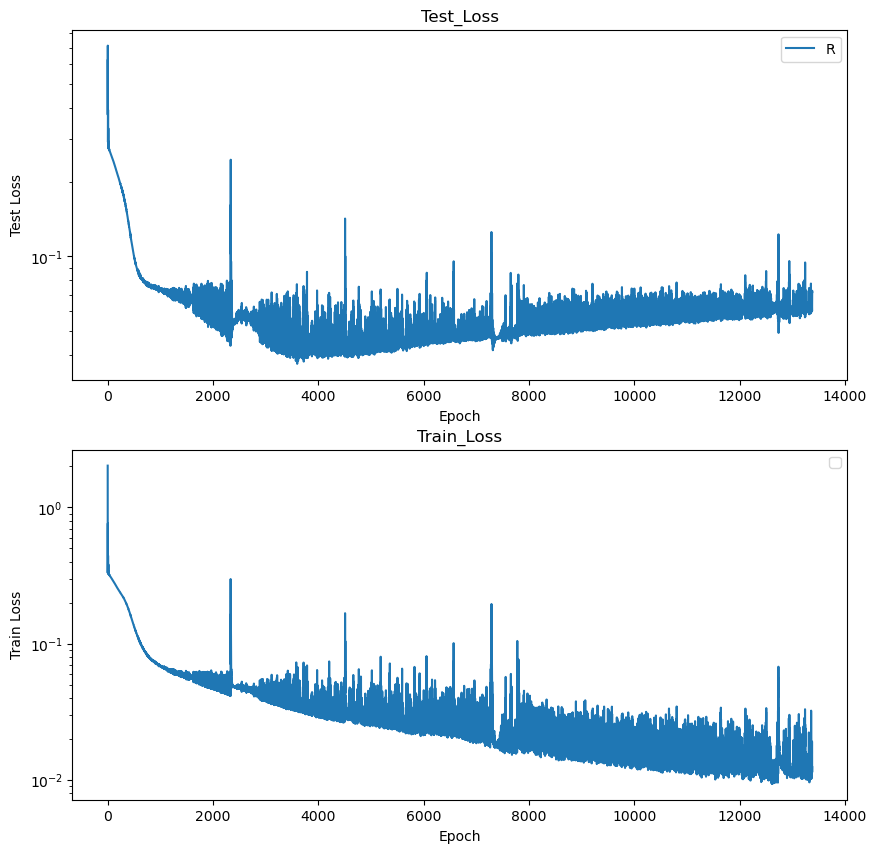

saving work is done
finish--------------------------------------------------------------------------------------------------------------------------------------------------------



No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


act:  ReLU opt:  Adam batch_size:  128 learningRate:  0.0005 epoch:  5851 , RMSE_Test: 0.21032 , RMSE_Train: 0.17708 , est_time:   5.0 min, average_time: 0.05 s
start to save model
start to save log
my_results/1695971815_0.21final.pt
, layer_dim_list: [2200, 1000, 100, 10, 1] activateion: ReLU , optimizer: Adam , Bsize: 128 , learningRate: 0.0005
, epoch:  5851 , passed_time: 5.001 m , minimum_RMSE: 0.17853 , test_loss: 0.210325 , train_loss: 0.177082 , passed_time_accum: 280.724 m model_save_time 1695971815
start to save figures


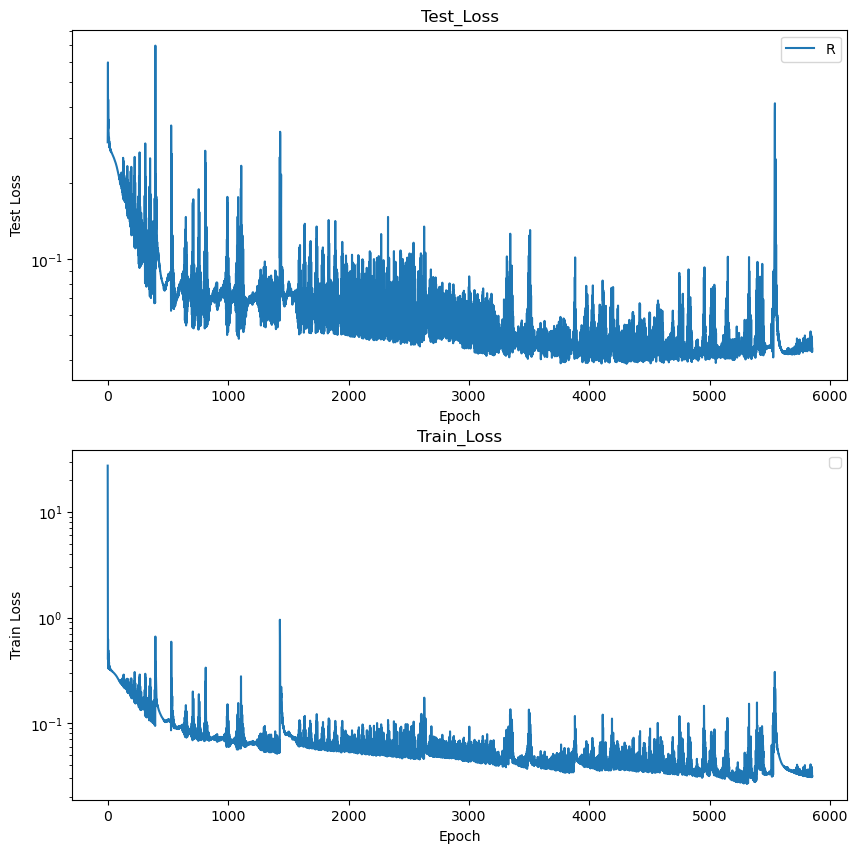

saving work is done
finish--------------------------------------------------------------------------------------------------------------------------------------------------------



No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


act:  ReLU opt:  Adam batch_size:  128 learningRate:  1e-05 epoch:  5650 , RMSE_Test: 0.23834 , RMSE_Train: 0.22073 , est_time:   5.0 min, average_time: 0.05 s
start to save model
start to save log
my_results/1695972115_0.23final.pt
, layer_dim_list: [2200, 1000, 100, 10, 1] activateion: ReLU , optimizer: Adam , Bsize: 128 , learningRate: 1e-05
, epoch:  5650 , passed_time: 5.001 m , minimum_RMSE: 0.17853 , test_loss: 0.238342 , train_loss: 0.220727 , passed_time_accum: 285.736 m model_save_time 1695972115
start to save figures


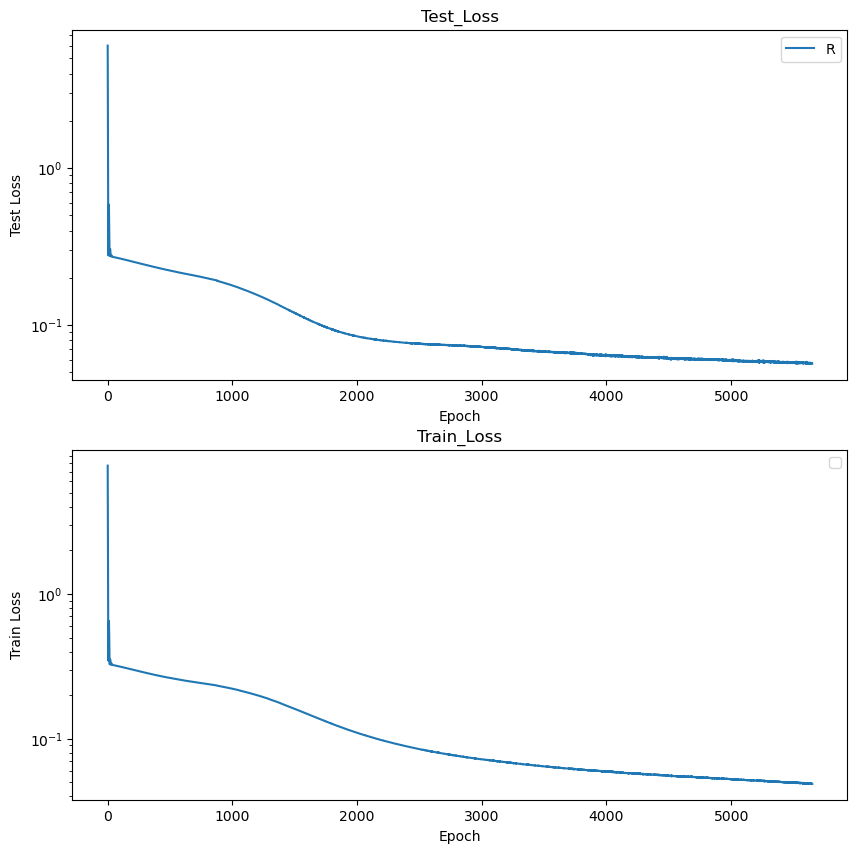

saving work is done
finish--------------------------------------------------------------------------------------------------------------------------------------------------------



No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


act:  ReLU opt:  Adam batch_size:  128 learningRate:  5e-05 epoch: 13249 , RMSE_Test: 0.25203 , RMSE_Train: 0.11372 , est_time:   5.0 min, average_time: 0.02 s
start to save model
start to save log
my_results/1695972416_0.25final.pt
, layer_dim_list: [2200, 1000, 100, 10, 1] activateion: ReLU , optimizer: Adam , Bsize: 128 , learningRate: 5e-05
, epoch: 13249 , passed_time: 5.000 m , minimum_RMSE: 0.17853 , test_loss: 0.252030 , train_loss: 0.113717 , passed_time_accum: 290.752 m model_save_time 1695972416
start to save figures


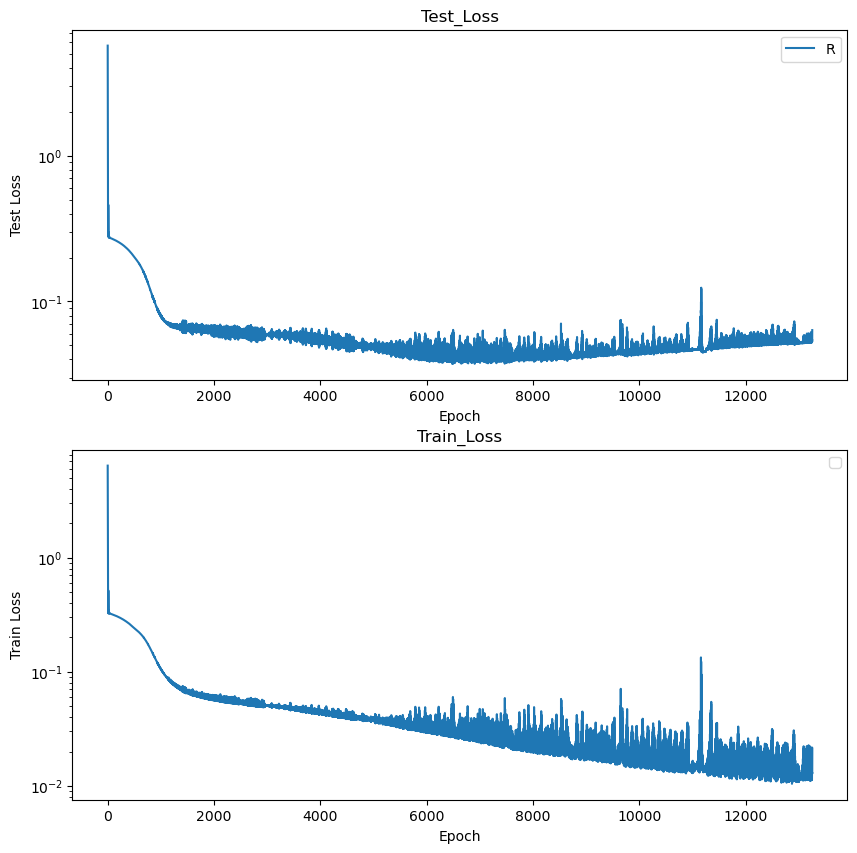

saving work is done
finish--------------------------------------------------------------------------------------------------------------------------------------------------------



No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


act:  ReLU opt:  Adam batch_size:  128 learningRate:  1e-06 epoch: 13279 , RMSE_Test: 0.26725 , RMSE_Train: 0.29387 , est_time:   5.0 min, average_time: 0.02 s
start to save model
start to save log
my_results/1695972717_0.26final.pt
, layer_dim_list: [2200, 1000, 100, 10, 1] activateion: ReLU , optimizer: Adam , Bsize: 128 , learningRate: 1e-06
, epoch: 13279 , passed_time: 5.000 m , minimum_RMSE: 0.17853 , test_loss: 0.267250 , train_loss: 0.293874 , passed_time_accum: 295.765 m model_save_time 1695972717
start to save figures


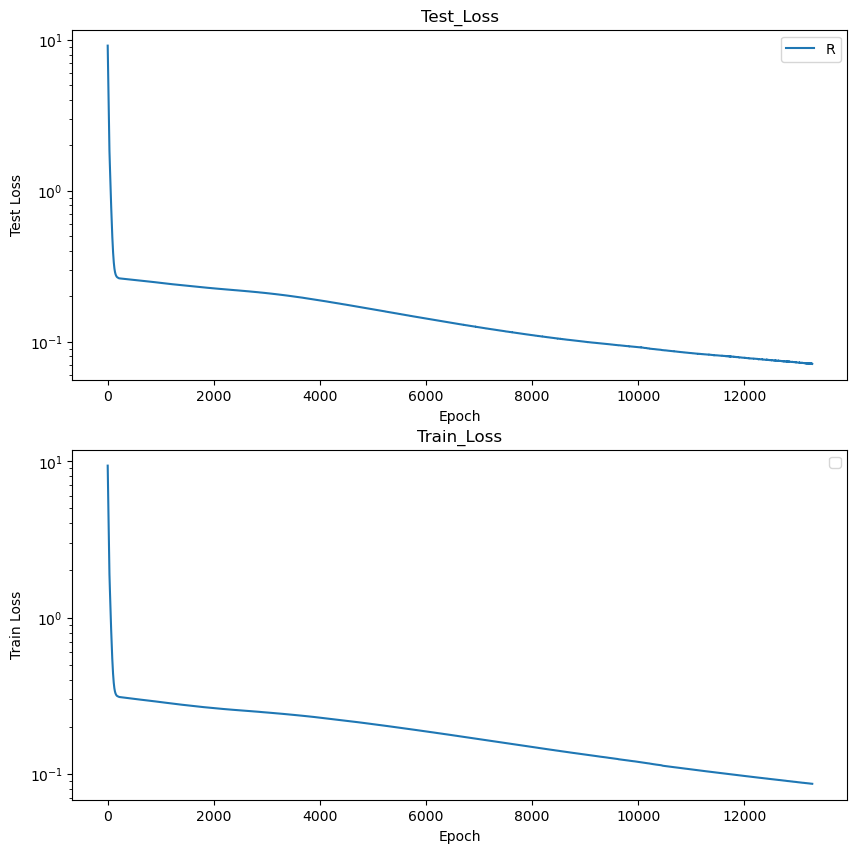

saving work is done
finish--------------------------------------------------------------------------------------------------------------------------------------------------------



No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


act:  ReLU opt:  Adam batch_size:  128 learningRate:  5e-06 epoch: 13376 , RMSE_Test: 0.21430 , RMSE_Train: 0.18810 , est_time:   5.0 min, average_time: 0.02 s
start to save model
start to save log
my_results/1695973018_0.21final.pt
, layer_dim_list: [2200, 1000, 100, 10, 1] activateion: ReLU , optimizer: Adam , Bsize: 128 , learningRate: 5e-06
, epoch: 13376 , passed_time: 5.000 m , minimum_RMSE: 0.17853 , test_loss: 0.214299 , train_loss: 0.188097 , passed_time_accum: 300.778 m model_save_time 1695973018
start to save figures


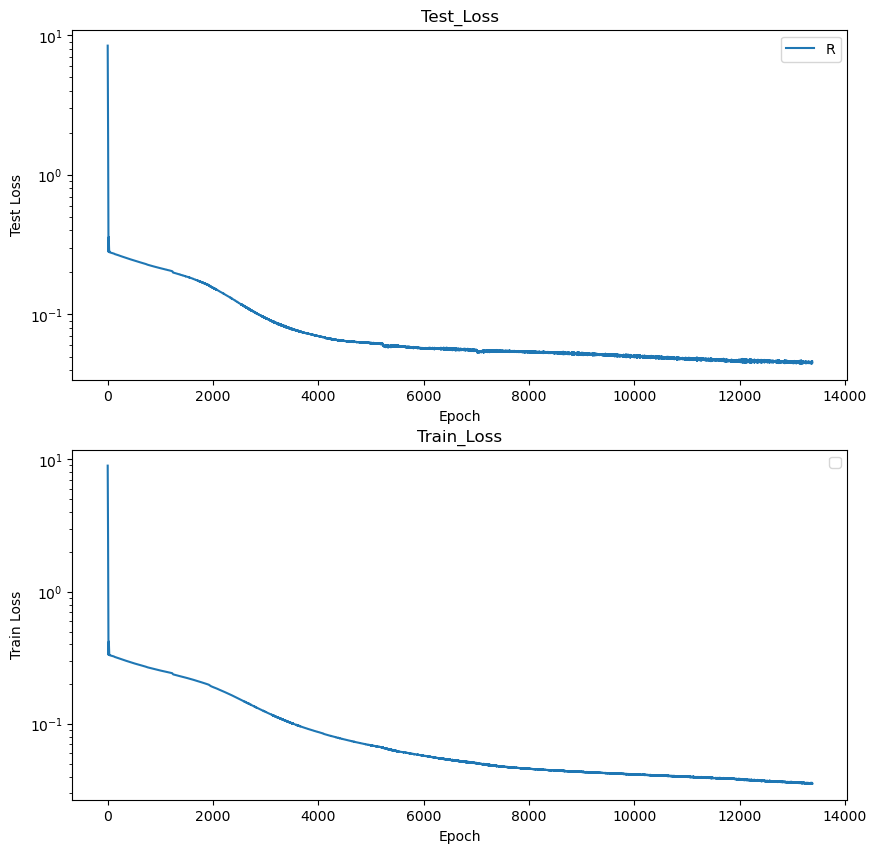

saving work is done
finish--------------------------------------------------------------------------------------------------------------------------------------------------------

These parameters showed the best performance!--------------------------------------------------------------------------------

all done


'\ncomment\n\n'

In [8]:

#default

"""
my_results/1695965799_0.24final.pt
, layer_dim_list: [2200, 1000, 100, 10, 1] activateion: ReLU , optimizer: Adam , Bsize: 32 , learningRate: 5e-06
, epoch:  2390 , passed_time: 5.001 m , minimum_RMSE: 0.17853 , RMSE_Test: 0.248401 , RMSE_Train: 0.282239 , passed_time_accum: 180.472 m model_save_time 1695965799

my_results/1695957980_0.20final.pt
, layer_dim_list: [2200, 1000, 100, 10, 1] activateion: ReLU , optimizer: Adam , Bsize: 8 , learningRate: 5e-05
, epoch:  1639 , passed_time: 5.001 m , minimum_RMSE: 0.19863 , RMSE_Test: 0.204672 , RMSE_Train: 0.045140 , passed_time_accum: 50.147 m model_save_time 1695957980

my_results/1695957378_0.26final.pt
, layer_dim_list: [2200, 1000, 100, 10, 1] activateion: ReLU , optimizer: Adam , Bsize: 8 , learningRate: 0.0005
, epoch:  1681 , passed_time: 5.003 m , minimum_RMSE: inf , RMSE_Test: 0.264832 , RMSE_Train: 0.147594 , passed_time_accum: 40.119 m model_save_time 1695957378
my_results/1695957679_0.27final.pt
"""
# for learningRate in range(10): #


# dim_list = [2, 100, 100, 100, 10, 1] 10 min: 0.03 loss
dim_list = [2200, 1000, 100, 10, 1]



f = open("mylog.txt", "a")
#If data is less complex and is having fewer dimensions or features then neural networks with 1 to 2 hidden layers would work.
# If data is having large dimensions or features then to get an optimum solution, 3 to 5 hidden layers can be used.

init_time = time.time()
best_record = ''
best_mse = np.inf   # init to infinity
best_weights = None
print('start')

for act in [
            # 'LeakyReLU',
            # 'LogSigmoid',
            # 'Softplus'
            'ReLU'
            ]:

    for opt in [
                # 'Adadelta',
                # 'Adagrad',
                'Adam',
                # 'AdamW',
                # 'SparseAdam',
                # 'Adamax',
                # 'ASGD',
                # 'LBFGS',
                # 'NAdam',
                # 'RAdam',
                # 'RMSprop',
                # 'Rprop',
                # 'SGD'
                ]:

        for batch_size in [ 8, 16, 32, 64, 128]:
        # for Bsize in [ 10, 100, 1000]:
        # for learningRate in [1e-4 ]:
        
            # for learningRate in [ 1e-1, 1e-2, 1e-3, 1e-4,1e-5, 1e-6, ]:
            for learningRate in [ 1e-1, 5e-1, 1e-2, 5e-2, 1e-3, 5e-3, 1e-4, 5e-4, 1e-5, 5e-5, 1e-6, 5e-6, ]:
            # for batch_size in [ 16]:
            # for batch_size in [ 8]:
                try:
                    make_model = 'model = nn.Sequential('
                    for layer_num in range( len(dim_list) - 1 ):
                        if layer_num == len(dim_list) - 2:
                            make_model = make_model + 'nn.Linear(dim_list[' + str(layer_num) + '], dim_list[' + str(layer_num+1) + ']) )'
                        else:
                            # make_model = make_model + 'nn.Linear(dim_list[' + str(layer_num) + '], dim_list[' + str(layer_num+1) + ']), nn.LeakyReLU(),'
                            make_model = make_model + 'nn.Linear(dim_list[' + str(layer_num) + '], dim_list[' + str(layer_num+1) + ']), nn.' + act + '(),'


                    exec(make_model)

                    exec('optimizer = optim.' + opt + '(model.parameters(), lr=learningRate  )')

                    batch_start = torch.arange(0, len(X_train), batch_size)

                    # Hold the best model

                    history = []
                    history_train = []


                    # for epoch in range(n_epochs):
                    second_time = time.time()

                    epoch = 0
                    len_batch = len(X_train)
                    loss_func = nn.MSELoss()
                    while(1):

                        model.train()

                        for start in range(0,len_batch, batch_size):

                            X_batch = X_train[start:start+batch_size] # 두번째 값이 길이를 초과해도 오류안뜨고 그냥 시작부터 끝까지 출력해주는 착한친구.
                            y_batch = y_train[start:start+batch_size]
                            # forward pass
                            y_pred = model(X_batch).squeeze()

                            # before_loss = torch.mean( (y_pred/y_batch-1)**2 + (y_batch/y_pred-1)**2 + (y_pred-y_batch)**2 )
                            # before_loss = torch.mean( (y_pred/y_batch-1)**2 + (y_batch/y_pred-1)**2  )

                            # loss = before_loss**(1/2)
                            loss = loss_func(y_pred,y_batch )

                            # backward pass
                            optimizer.zero_grad()
                            loss.backward()

                            # update weights
                            optimizer.step()

                        loss = float(loss)

                        history_train.append(loss)

                        model.eval()
                        y_pred = model(X_test).squeeze()
                        #print(y_pred)

                        # before_loss = torch.mean(  (y_pred/y_test-1)**2 + (y_test/y_pred-1)**2 + (y_pred-y_test)**2 )
                        # before_loss = torch.mean(  (y_pred/y_test-1)**2 + (y_test/y_pred-1)**2   )

                        # mse = before_loss**(1/2)
                        mse = loss_func(y_pred, y_test)

                        mse = float(mse)

                        history.append(mse)
                        
                        if mse<1:
                            model_file_name = 'my_results/'+str(int(second_time)) +'_'+ str( mse**(1/2) )[:4] + '.pt'
                        elif best_mse==np.inf:
                            pass
                        else:
                            model_file_name = 'my_results/'+str(int(second_time)) +'_'+ str( int(mse**(1/2)) ) + '.pt'

                        if mse < best_mse and mse**(1/2) < 0.15:
                            best_mse = mse
                            # best_weights = copy.deepcopy(model.state_dict())
                            model_file_name.split('.pt')[0] + 'best.pt'
                            torch.save(model, model_file_name )
                            best_record =  (
                                            model_file_name,

                                            ', layer_dim_list:', dim_list,
                                            'activateion:', act,
                                            ', optimizer:', opt,
                                            ', Bsize:', batch_size ,
                                            ', learningRate:', learningRate ,

                                            ', epoch: %5d' % epoch,
                                            ', passed_time: %.3f' % ( ( time.time()-second_time )  / 60  ),  'm',

                                            ", minimum_RMSE: %.5f" % (best_mse**(1/2)),
                                            ', test_loss: %5f' % (mse),
                                            ', train_loss: %5f' % (loss),
                                            ', passed_time_accum: %.3f' % ( ( time.time() -init_time )  / 60  ),  'm',

                                            )
                            
                            fig, axs = plt.subplots(2, 1, figsize=(10, 5*2))#, sharey=True)
                            axs[0].set_xlabel('Epoch', fontsize=10)
                            axs[0].set_ylabel(r'Test Loss', fontsize=10)
                            axs[0].legend()
                            axs[0].plot(history, )
                            axs[0].set_yscale('log')
                            axs[0].set_title('Test_Loss')
                            axs[0].legend("RMSE:"+str( mse**(1/2) )+ "_"+str(act)+ "_"+str(opt)+"_"+str(batch_size)+"_"+ str(learningRate))


                            axs[1].set_xlabel('Epoch', fontsize=10)
                            axs[1].set_ylabel(r'Train Loss', fontsize=10)
                            axs[1].legend()
                            axs[1].plot(history_train)
                            axs[1].set_yscale('log')
                            axs[1].set_title('Train_Loss')

                            # fig.legend(l1, ( str(act)+ "_"+str(opt)+"_"+str(Bsize)+"_"+ str(learningRate) +'_'+str(elapsed_time) ) )#, loc='upper left')
                            # fig.legend(l2, ( str(act)+ "_"+str(opt)+"_"+str(Bsize)+"_"+ str(learningRate) +'_'+str(elapsed_time) ) )#, loc='upper right')

                            # plt.legend([str(act)+ "_"+str(opt)+"_"+str(Bsize)+"_"+ str(learningRate) +'_'+str(elapsed_time)])#, fontsize="x-large")

                            plt.savefig(
                                        # (model_file_name.split('/')[0]+'/best_'+ model_file_name.split('/')[1])[0:-3] + 'Loss' + '.pdf',
                                        model_file_name,
                                        format="pdf",
                                        bbox_inches="tight"
                                        )

                        # if epoch % 1000 == 0:
                        if mse < best_mse and mse**(1/2) < 0.2:
                            best_mse = mse
                        # if ( time.time()-second_time )  / 60 == 0:
                            # print('epoch: %5d' % epoch, 'test_loss: %.2f' % (mse), 'train_loss: %.2f' % (loss), 'est_time: %.2f' % (( ( epoch_time ) / (epoch+1) ) / 60 * (n_epochs-epoch) ) ,'min', "epoch_time:", epoch_time, 's')
                            print_progress(act, opt, batch_size, learningRate, epoch, mse, loss, second_time)
                            # print('{:.6}'.format(val))
                            # print("{:10.4f}".format(x))

                        # if (mse<10) or (str(mse)=='nan') or ( ( ( time.time()-second_time ) )  / 60 > 0.1  ):
                        # if (mse**(1/2) < 0.005) or (str(mse)=='nan'): # 1~10 까지의 값 중에서  E 의 최솟값은 0.05이다. 그런데 이 값의 1퍼센트 오차인
                        if (mse**(1/2) < 0.1) or (str(mse)=='nan') or ( ( ( time.time()-second_time ) )  / 60 > 5 ):
                        # if (mse**(1/2) < 0.1) or (str(mse)=='nan') :
                            print_progress(act, opt, batch_size, learningRate, epoch, mse, loss, second_time)
                            save_my_work(model, f, opt, batch_size, learningRate, epoch, second_time, best_mse, mse, loss, init_time, model_file_name.split('.pt')[0] + 'final.pt'  )
                            break
                        epoch = epoch + 1

                    # restore model and return best accuracy
                    # model.load_state_dict(best_weights)
                    # print("MSE: %.2f" % best_mse)
                    # print("RMSE: %.2f" % np.sqrt(best_mse))


                    print('finish--------------------------------------------------------------------------------------------------------------------------------------------------------')
                    print('')

                except:
                    # os.mkdir('/content/drive/MyDrive/0_318lab/SCMP_ML/')
                    print('error has occured')
                    save_my_work(model, f, opt, batch_size, learningRate, epoch, second_time, best_mse, mse, loss, init_time, model_file_name.split('.pt')[0] + 'error.pt' )

f.close()
print('These parameters showed the best performance!--------------------------------------------------------------------------------')
print(best_record)
print('all done')
# ----------------------------------------------------------------------------------------------------
# ----------------------------------------------------------------------------------------------------
'''
comment

'''


In [6]:
'1.123.123.pt'.split('.pt')

['1.123.123', '']

In [47]:
model_file_name

'my_results/1695954029_0.53.pt'

In [44]:
                            print_progress(act, opt, batch_size, learningRate, epoch, mse, loss, second_time)


act:  ReLU opt:  Adam batch_size:  8 learningRate:  0.0001 epoch: 4257652 , RMSE_Test: 0.30158 , RMSE_Train: 0.08346 , est_time: 2429.8 min, average_time: 0.03 s


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


start to save model
start to save log
my_results/error_model_1695807409_best_0.30.pt
, layer_dim_list: [2200, 100, 100, 10, 1] activateion: ReLU , optimizer: Adam , Bsize: 8 , learningRate: 0.0001
, epoch: 4257652 , passed_time: 2403.212 m , minimum_RMSE: 0.18821 , test_loss: 0.301583 , train_loss: 0.083460 , passed_time_accum: 2403.212 m model_save_time 1695807409
start to save figures


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


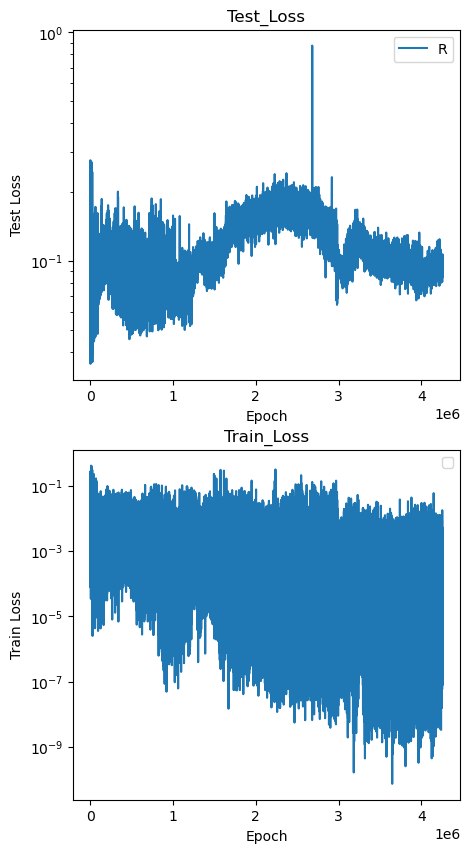

saving work is done


In [42]:
save_my_work(model, f, opt, batch_size, learningRate, epoch, second_time, best_mse, mse, loss, init_time, model_file_name.split('/')[0]+'/error_'+ model_file_name.split('/')[1])


In [28]:
model_file_name

'my_results/model_1695790679_best_0.19.pt'

In [43]:
torch.cuda.is_available()

False

In [29]:
model_file_name.split('/')[0]+'/final_'+ model_file_name.split('/')[1]

'my_results/final_model_1695790679_best_0.19.pt'

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


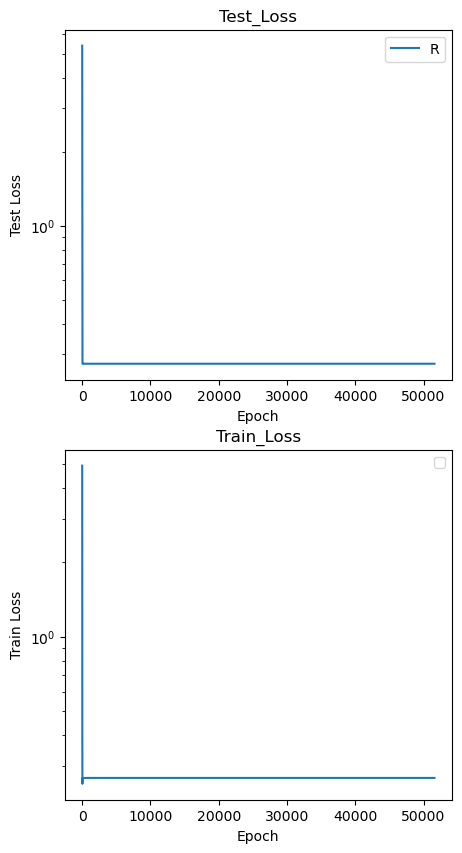

In [26]:
# learningRate : -3,-4
fig, axs = plt.subplots(2, 1, figsize=(5, 5*2))#, sharey=True)
axs[0].set_xlabel('Epoch', fontsize=10)
axs[0].set_ylabel(r'Test Loss', fontsize=10)
axs[0].legend()
axs[0].plot(history, )
axs[0].set_yscale('log')
axs[0].set_title('Test_Loss')
axs[0].legend("RMSE:"+str( mse**(1/2) )+ "_"+str(act)+ "_"+str(opt)+"_"+str(batch_size)+"_"+ str(learningRate))


axs[1].set_xlabel('Epoch', fontsize=10)
axs[1].set_ylabel(r'Train Loss', fontsize=10)
axs[1].legend()
axs[1].plot(history_train)
axs[1].set_yscale('log')
axs[1].set_title('Train_Loss')

# fig.legend(l1, ( str(act)+ "_"+str(opt)+"_"+str(Bsize)+"_"+ str(learningRate) +'_'+str(elapsed_time) ) )#, loc='upper left')
# fig.legend(l2, ( str(act)+ "_"+str(opt)+"_"+str(Bsize)+"_"+ str(learningRate) +'_'+str(elapsed_time) ) )#, loc='upper right')

# plt.legend([str(act)+ "_"+str(opt)+"_"+str(Bsize)+"_"+ str(learningRate) +'_'+str(elapsed_time)])#, fontsize="x-large")

plt.show()